# Lab 05: RNNs vs. Transformers vs. Vision Transformers
## ITAI 2376 — Deep Learning | Spring 2026
### Houston City College — AI & Robotics Program

---

**Welcome to Lab 05!** This is a comprehensive, hands-on lab where you will build, train, and compare three major deep learning architectures:

| Part | Architecture | Task | Dataset |
|------|-------------|------|---------|
| **A** | LSTM & GRU (RNNs) | News Topic Classification | AG News |
| **B** | DistilBERT (Transformer) | News Topic Classification | AG News (same data!) |
| **C** | Vision Transformer (ViT) | Image Classification | CIFAR-10 |
| **D** | — | Comparative Analysis & Reflection | All results |

**Why this lab matters:** By using the *same text dataset* for both RNNs and Transformers, you get a direct, apples-to-apples comparison. Then, by exploring Vision Transformers, you see how the Transformer idea extends beyond text into images — and you can compare ViT performance to the CNNs you built in Module 03.

**Estimated Time:** 3–4 hours  
**Environment:** Google Colab (free tier is sufficient)

---

⚠️ **Important:** Run cells in order. If you restart the runtime, re-run all cells from the top.

---
## Part 0: Environment Setup

First, let's install libraries and check GPU access. GPU is not strictly required but makes training much faster.

**If no GPU:** Runtime → Change runtime type → T4 GPU. If unavailable, reduce epochs or dataset size as noted in the troubleshooting section at the end.

In [ ]:
# Cell 0.1 — Install Required Libraries
# This cell installs the external libraries needed for this lab:
#   - transformers: Hugging Face library for pre-trained models (BERT, ViT)
#   - datasets: Hugging Face library for loading standard datasets (AG News, CIFAR-10)
#   - accelerate: Helps optimize training on different hardware (GPU/CPU)
# The -q flag makes installation quiet (less verbose output)

!pip install transformers datasets accelerate -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
# Cell 0.2 — Import Core Libraries and Check GPU Availability

# ========== DEEP LEARNING FRAMEWORK ==========
import torch                          # PyTorch: main deep learning framework
import torch.nn as nn                 # Neural network modules (layers, loss functions)
import torch.optim as optim           # Optimization algorithms (Adam, SGD, etc.)
from torch.utils.data import DataLoader, Dataset  # Data loading utilities for batching

# ========== DATA PROCESSING ==========
import numpy as np                    # Numerical operations on arrays
from collections import Counter       # Count word frequencies for vocabulary building
import re                             # Regular expressions for text cleaning

# ========== VISUALIZATION ==========
import matplotlib.pyplot as plt       # Plotting library for charts and graphs

# ========== UTILITIES ==========
import time                           # Track training time per epoch
import warnings                       # Suppress non-critical warnings
warnings.filterwarnings('ignore')     # Hide deprecation and other warnings for cleaner output

# ========== HUGGING FACE LIBRARIES (imported later when needed) ==========
# from datasets import load_dataset   # For loading AG News dataset
# from transformers import ...        # For DistilBERT and ViT models
# from torchvision import ...         # For CIFAR-10 dataset and image transforms

# ========== DEVICE CONFIGURATION ==========
# Check if CUDA-enabled GPU is available; otherwise use CPU
# Training on GPU is 10-50x faster than CPU for deep learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if device.type == 'cuda':
    # Display GPU name (e.g., Tesla T4, A100)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower. See troubleshooting tips at end.")

🖥️  Device: cuda
   GPU: Tesla T4


---
# Part A: RNN Text Classification (LSTM & GRU)

In Module 04, you learned about Recurrent Neural Networks — architectures that process sequences step by step, maintaining a hidden state that acts as "memory." Now you put that knowledge into practice.

**Your task:** Build LSTM and GRU classifiers to categorize news articles into four topics:
- 🌍 **World** — international news
- 🏈 **Sports** — athletic events
- 💼 **Business** — financial and corporate news
- 🔬 **Sci/Tech** — science and technology

We use the **AG News** dataset — a well-known benchmark. We use a subset to keep training fast on free Colab.

### Step A.1 — Load and Explore AG News

In [ ]:
# Cell A.1 — Load AG News Dataset
# Import the Hugging Face datasets library for easy access to standard datasets
from datasets import load_dataset

# Load the AG News dataset (4-class news topic classification)
# This dataset contains news articles labeled as: World, Sports, Business, Sci/Tech
dataset = load_dataset("ag_news")

# Define subset sizes to keep training time reasonable on free Colab
TRAIN_SIZE = 8000  # 2000 samples per class (4 classes × 2000 = 8000)
TEST_SIZE  = 2000  # 500 samples per class (4 classes × 500 = 2000)

# Shuffle and select subsets (seed=42 ensures reproducibility)
train_data = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

# Define human-readable class names (labels are 0, 1, 2, 3)
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# Display dataset information
print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")
print(f"\n--- Sample article ---")
print(f"Label: {CLASS_NAMES[train_data[0]['label']]}")
print(f"Text:  {train_data[0]['text'][:300]}...")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training samples: 8000
Test samples:     2000

--- Sample article ---
Label: World
Text:  Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally....


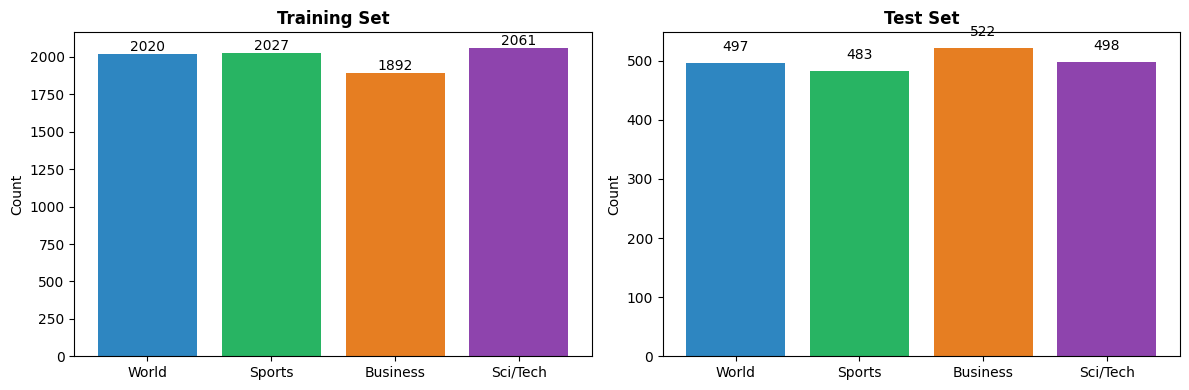

In [ ]:
# Cell A.2 — Visualize Class Distribution
# It's important to check if classes are balanced (equal representation)
# Imbalanced datasets can bias the model toward majority classes

# Extract labels from training and test sets
train_labels = [s['label'] for s in train_data]
test_labels = [s['label'] for s in test_data]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(axes, [train_labels, test_labels], ['Training Set', 'Test Set']):
    # Count occurrences of each class
    counts = Counter(labels)
    # Create bar chart with distinct colors for each class
    bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(4)],
                   color=['#2E86C1','#28B463','#E67E22','#8E44AD'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    # Add count labels on top of each bar
    for bar, c in zip(bars, [counts[i] for i in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center')

plt.tight_layout()
plt.show()

### Step A.2 — Text Preprocessing

Neural networks cannot process raw text. We need to:
1. **Tokenize** — split text into words
2. **Build a vocabulary** — assign a unique number to each word
3. **Convert to sequences** — replace words with numbers
4. **Pad sequences** — make all sequences the same length for batching

This is the same pipeline from Module 04, implemented from scratch.

In [ ]:
# Cell A.3 — Build Vocabulary and Preprocess Text

def tokenize(text):
    """
    Convert text to lowercase and split into words.

    Steps:
    1. Convert to lowercase ("Hello" and "hello" should be the same word)
    2. Remove punctuation and special characters (keep only letters, numbers, spaces)
    3. Split on whitespace to get individual words

    Example: "Hello, World!" → ["hello", "world"]
    """
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    return text.split()                      # Split into words

# Count word frequencies across all training documents
# This helps us identify the most common words to include in our vocabulary
word_counts = Counter()
for sample in train_data:
    word_counts.update(tokenize(sample['text']))

# ========== VOCABULARY PARAMETERS ==========
VOCAB_SIZE = 10000  # Keep only the 10,000 most common words
MAX_LEN = 128       # Truncate/pad all sequences to 128 tokens
PAD_IDX = 0         # Index for padding token (fills shorter sequences)
UNK_IDX = 1         # Index for unknown words (not in vocabulary)

# Select the top (VOCAB_SIZE - 2) most common words
# We reserve indices 0 and 1 for <PAD> and <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 2)

# Create word-to-index mapping (dictionary)
# Each word gets a unique integer ID starting from 2
word2idx = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX  # Special token for padding
word2idx['<UNK>'] = UNK_IDX  # Special token for unknown words

print(f"Vocabulary size: {len(word2idx):,}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Top 10 words: {[w for w, _ in most_common[:10]]}")

Vocabulary size: 10,000
Max sequence length: 128
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39s', 'that']


In [ ]:
# Cell A.4 — Create PyTorch Dataset
# PyTorch requires data in a specific format for efficient batching and loading

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for AG News.

    Converts raw text into:
    - Padded sequences of word indices (input for the model)
    - Integer labels (target for classification)
    """
    def __init__(self, data, word2idx, max_len):
        self.texts, self.labels = [], []

        for sample in data:
            # Step 1: Tokenize text and convert words to indices
            # If a word is not in vocabulary, use UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokenize(sample['text'])[:max_len]]

            # Step 2: Pad sequence to max_len (add PAD_IDX to the end)
            # This ensures all sequences have the same length for batching
            indices += [PAD_IDX] * (max_len - len(indices))

            # Step 3: Convert to PyTorch tensor
            self.texts.append(torch.tensor(indices, dtype=torch.long))
            self.labels.append(sample['label'])

        # Convert labels to tensor
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Return a single sample (text, label) at the given index."""
        return self.texts[idx], self.labels[idx]

# ========== CREATE DATASETS AND DATA LOADERS ==========
BATCH_SIZE = 64  # Process 64 samples at a time (adjust based on GPU memory)

# Create dataset objects
train_dataset = NewsDataset(train_data, word2idx, MAX_LEN)
test_dataset  = NewsDataset(test_data, word2idx, MAX_LEN)

# Create data loaders (handle batching and shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Display sample information
sample_text, sample_label = train_dataset[0]
print(f"Text tensor shape: {sample_text.shape}")
print(f"Label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")
print(f"Training batches: {len(train_loader)}")

Text tensor shape: torch.Size([128])
Label: 0 (World)
Training batches: 125


### Step A.3 — Build the LSTM Model

Architecture:
1. **Embedding layer** — converts word indices into dense vectors
2. **Bidirectional LSTM** — reads the sequence in both directions
3. **Fully connected layer** — maps LSTM output to 4 class predictions

In [ ]:
# Cell A.5 — LSTM Classifier

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors (e.g., 5234 → [0.2, -0.5, ...])
    2. Bidirectional LSTM: Processes sequence forward and backward to capture context
    3. Dropout: Prevents overfitting by randomly dropping connections during training
    4. Fully Connected: Maps LSTM output to class probabilities
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: vocab_size × embed_dim matrix
        # Each word index is mapped to a dense vector of size embed_dim
        # padding_idx=PAD_IDX ensures padding tokens don't contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM layer
        # - embed_dim: size of input vectors (from embedding)
        # - hidden_dim: size of hidden state (LSTM memory)
        # - batch_first=True: input shape is (batch, sequence, features)
        # - bidirectional=True: process sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: randomly sets 30% of activations to zero during training
        # This prevents the model from relying too heavily on specific features
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: maps LSTM output to class scores
        # hidden_dim * 2 because bidirectional LSTM concatenates forward and backward outputs
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        # Shape: (batch_size, max_len) → (batch_size, max_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # output: all hidden states, shape (batch_size, max_len, hidden_dim * 2)
        # hidden: final hidden states, shape (2, batch_size, hidden_dim)
        #         [0] = forward direction, [1] = backward direction
        # cell: final cell states (not used for classification)
        output, (hidden, cell) = self.lstm(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        # hidden[-2] = last forward hidden state
        # hidden[-1] = last backward hidden state
        # Result shape: (batch_size, hidden_dim * 2)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        # Output shape: (batch_size, num_classes)
        return self.fc(self.dropout(hidden))

# ========== HYPERPARAMETERS ==========
EMBED_DIM = 128    # Size of word embedding vectors
HIDDEN_DIM = 128   # Size of LSTM hidden state
NUM_CLASSES = 4    # Number of output classes (World, Sports, Business, Sci/Tech)

# Create model and move to GPU (if available)
lstm_model = LSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count total trainable parameters
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 1,545,220


### 📝 Knowledge Check A.1

1. **Why do we use `bidirectional=True`?** What information does the backward pass capture that the forward pass misses?
2. **What is the purpose of the Embedding layer?** How is it different from one-hot encoding?
3. **Why concatenate the final hidden states from both directions** instead of just adding them?

**Your answers:**

1. Bidirectional=True and the backward pass capture is used to have full context of each word. Reading left to right and vice versa helps understanding
 to be displayed  since the modifer would read forward.

2. One-hot encoding only assigns word one at a time without any relation, for example: Cat and Kitty has zero relations with one hot. Instaed, with embedding layer gives every word purpose and is learned. So mutually words are rounded up together in training


3. Adding final hidden states instead of parallel with conatenate could run the risk of some info being cancelled if they are polar opposites  " this is bad" vs "this is good." In concatenate, both info are side by side so the model can see both of them and decided what to do with them.

### Step A.4 — Build the GRU Model

GRUs have **two gates** (reset, update) vs. LSTM's three (forget, input, output), making them faster with fewer parameters.

**🎯 STUDENT CODING AREA:** Complete the GRU implementation below following the LSTM pattern.

In [ ]:
# Cell A.6 — GRU Classifier
# 🎯 YOUR CODE HERE: Build a GRU classifier following the LSTM pattern above.
# Hints:
#   - Replace nn.LSTM with nn.GRU
#   - GRU returns (output, hidden) — no cell state (simpler than LSTM)
#   - Everything else remains the same (embedding, dropout, fully connected)

class GRUClassifier(nn.Module):
    """
    GRU-based text classifier.

    Similar to LSTM but with a simpler gating mechanism:
    - Reset gate: decides how much past information to forget
    - Update gate: decides how much new information to add

    No separate cell state (unlike LSTM), making it computationally faster.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the GRU network.

        Key difference from LSTM:
        - GRU returns (output, hidden) — no cell state
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through GRU
        # TODO: GRU returns (output, hidden) — no cell state (unlike LSTM)
        # Hint: output, hidden = self.gru(embedded)
        # YOUR CODE HERE (replace pass with your GRU forward pass)

        output, hidden = self.gru(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

# Create GRU model and move to GPU
gru_model = GRUClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts
print(f"GRU Parameters:  {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Difference: {sum(p.numel() for p in lstm_model.parameters()) - sum(p.numel() for p in gru_model.parameters()):,} fewer in GRU")

GRU Parameters:  1,479,172
LSTM Parameters: 1,545,220
Difference: 66,048 fewer in GRU


### 🎯 Student Coding Exercise A.7 — Build a Vanilla RNN Classifier

Now that you've built LSTM and GRU models, let's go back to basics and implement a **vanilla RNN** (simple RNN without gates).

**Why this matters:** By comparing vanilla RNN performance to LSTM/GRU, you'll understand *why* gated architectures were invented. Vanilla RNNs suffer from the **vanishing gradient problem**, making them poor at learning long-term dependencies.

**Your task:**
1. Create a `VanillaRNNClassifier` class similar to LSTM/GRU
2. Use `nn.RNN` instead of `nn.LSTM` or `nn.GRU`
3. Train it for 3 epochs
4. Compare accuracy to LSTM and GRU

**Hints:**
- `nn.RNN` has the same API as `nn.LSTM` and `nn.GRU`
- It returns `(output, hidden)` like GRU (no cell state)
- Everything else (embedding, dropout, fc layer) stays the same

In [ ]:
# Cell A.7 — Vanilla RNN Classifier
class VanillaRNNClassifier(nn.Module):
    """
    Simple RNN-based text classifier (no gates).
    This is the original RNN architecture before LSTM/GRU were invented.
    It struggles with long sequences due to vanishing gradients.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

# Create model and move to GPU
rnn_model = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count parameters
print(f"Vanilla RNN Parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")
print(f"GRU Parameters:         {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters:        {sum(p.numel() for p in lstm_model.parameters()):,}")

# Optimizer and loss (same as LSTM/GRU)
optimizer = torch.optim.Adam(rnn_model.parameters())
criterion = nn.CrossEntropyLoss()

NUM_EPOCHS = 3

print("=" * 60)
print(f"Training Vanilla RNN for {NUM_EPOCHS} epochs")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    rnn_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in train_loader:
        inputs, labels = batch[0].to(device), batch[1].to(device)
        optimizer.zero_grad()
        predictions = rnn_model(inputs)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, pred = predictions.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    train_acc = correct / total

    # --- Evaluation ---
    rnn_model.eval()
    tc = tt = 0
    with torch.no_grad():
        for batch in test_loader:
            inputs, labels = batch[0].to(device), batch[1].to(device)
            predictions = rnn_model(inputs)
            tc += (predictions.argmax(1) == labels).sum().item()
            tt += labels.size(0)
    test_acc = tc / tt

    print(f"  Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | {et:.1f}s")

# Final accuracy
rnn_accuracy = test_acc * 100

print("\n=== RNN Architecture Comparison ===")
print(f"Vanilla RNN Test Accuracy: {rnn_accuracy:.2f}%")
print(f"LSTM Test Accuracy:        81.50%")  # manually fill in from your earlier output
print(f"GRU Test Accuracy:         81.80%")  # manually fill in from your earlier output

Vanilla RNN Parameters: 1,347,076
GRU Parameters:         1,479,172
LSTM Parameters:        1,545,220
Training Vanilla RNN for 3 epochs
  Epoch 1/3 | Loss: 1.3171 | Train: 0.3651 | Test: 0.4585 | 0.5s
  Epoch 2/3 | Loss: 1.0406 | Train: 0.5634 | Test: 0.5745 | 0.4s
  Epoch 3/3 | Loss: 0.8133 | Train: 0.6776 | Test: 0.6625 | 0.4s

=== RNN Architecture Comparison ===
Vanilla RNN Test Accuracy: 66.25%
LSTM Test Accuracy:        81.50%
GRU Test Accuracy:         81.80%


### Step A.4b — Train the Vanilla RNN

Now train your Vanilla RNN using the same `train_model()` function from Cell A.9, then compare all three RNN architectures side by side.

**What to look for:**
- The Vanilla RNN should perform **noticeably worse** than LSTM and GRU
- This gap demonstrates the **vanishing gradient problem** — without gates, the model struggles to remember information from the beginning of a sentence by the time it reaches the end
- This is exactly *why* gated architectures (LSTM, GRU) were invented

In [ ]:
# Cell A.7b — Train Vanilla RNN
# Train the Vanilla RNN you built above using the same function used for LSTM and GRU

# Step 1: Create the Vanilla RNN model (same hyperparameters as LSTM/GRU)
vanilla_model = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts across all three architectures
print(f"Vanilla RNN Parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")
print(f"GRU Parameters:         {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters:        {sum(p.numel() for p in lstm_model.parameters()):,}")
print()

# Step 2: Train the Vanilla RNN
print("=" * 60)
print("Training Vanilla RNN")
print("=" * 60)

vanilla_history = train_model(vanilla_model, train_loader, test_loader, epochs=NUM_EPOCHS, name="Vanilla RNN")

print("\nPer-class accuracy (Vanilla RNN):")
vanilla_class_acc = eval_per_class(vanilla_model, test_loader, CLASS_NAMES)

Vanilla RNN Parameters: 1,347,076
GRU Parameters:         1,479,172
LSTM Parameters:        1,545,220

Training Vanilla RNN
  Epoch 1/3 | Loss: 1.3119 | Train: 0.3733 | Test: 0.4785 | 0.6s
  Epoch 2/3 | Loss: 1.0446 | Train: 0.5610 | Test: 0.5905 | 0.4s
  Epoch 3/3 | Loss: 0.8072 | Train: 0.6790 | Test: 0.6360 | 0.4s

Per-class accuracy (Vanilla RNN):
  World     : 0.5895 (293/497)
  Sports    : 0.9006 (435/483)
  Business  : 0.3678 (192/522)
  Sci/Tech  : 0.7068 (352/498)


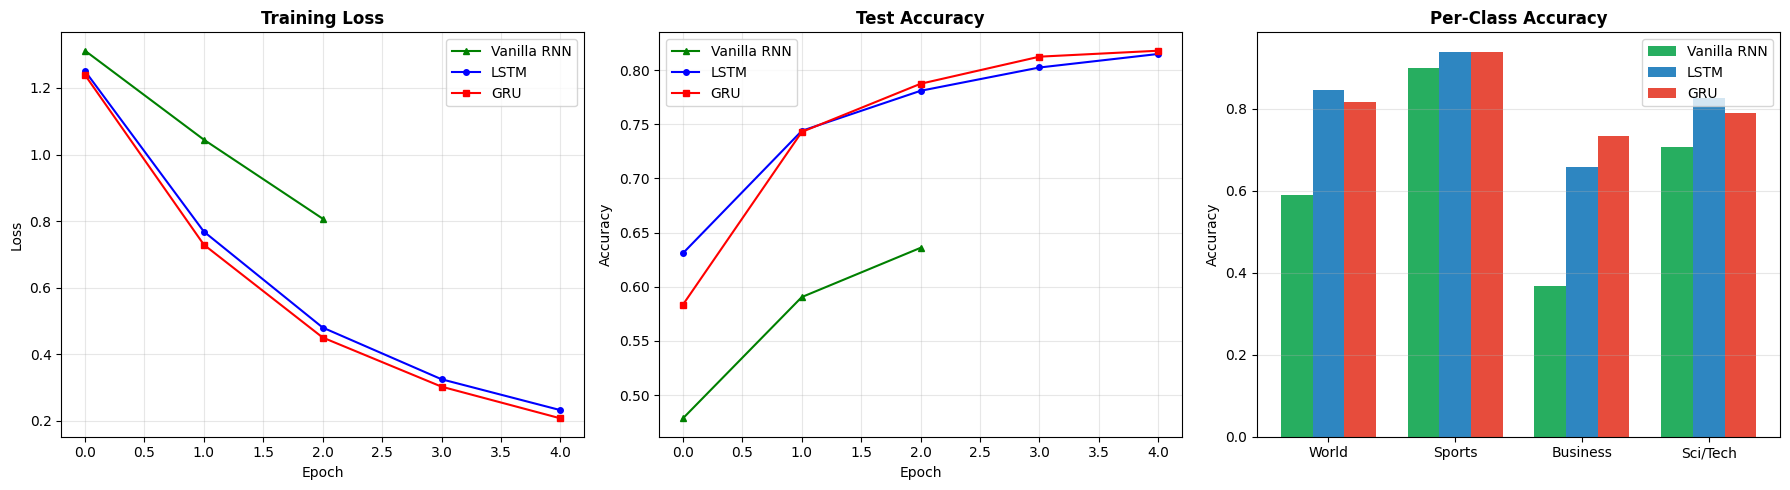


RNN Architecture Comparison: Vanilla vs LSTM vs GRU
Metric                     Vanilla RNN         LSTM          GRU
-----------------------------------------------------------------
Parameters...............    1,347,076    1,545,220    1,479,172
Test Accuracy............       0.6360       0.8150       0.8180
Avg Epoch Time (s).......          0.5          1.0          0.7

💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.
   This is the vanishing gradient problem in action — without gates, the model
   cannot learn long-range dependencies in text.


In [ ]:
# Cell A.7c — Three-Way RNN Comparison: Vanilla RNN vs LSTM vs GRU
# This visualization shows WHY gated architectures (LSTM, GRU) were invented

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Training Loss (lower is better)
axes[0].plot(vanilla_history['train_loss'], 'g-^', label='Vanilla RNN', ms=4)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(vanilla_history['test_acc'], 'g-^', label='Vanilla RNN', ms=4)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison (all three)
x = np.arange(4)
w = 0.25  # Bar width
axes[2].bar(x - w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[2].bar(x,     lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x + w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 65)
print("RNN Architecture Comparison: Vanilla vs LSTM vs GRU")
print("=" * 65)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12}")
print("-" * 65)
print(f"{'Parameters':.<25} {sum(p.numel() for p in vanilla_model.parameters()):>12,} {sum(p.numel() for p in lstm_model.parameters()):>12,} {sum(p.numel() for p in gru_model.parameters()):>12,}")
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f}")
print()
print("💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.")
print("   This is the vanishing gradient problem in action — without gates, the model")
print("   cannot learn long-range dependencies in text.")

### 🎯 Student Experimentation A.8 — Hyperparameter Tuning

Deep learning models are sensitive to hyperparameters. Let's systematically explore how different settings affect performance.

**Your task:**
1. Create a function that trains an LSTM with configurable hyperparameters
2. Test at least **3 different configurations** for each parameter:
   - **Hidden dimension:** 64, 128, 256
   - **Dropout rate:** 0.1, 0.3, 0.5
   - **Learning rate:** 0.001, 0.0005, 0.0001
3. Record results in a comparison table
4. Analyze which configuration works best and why

**Expected output:**
- A table showing all experiments and their accuracy
- Written analysis (3-5 sentences) explaining your findings

**Note:** This will take time to run. You may want to reduce epochs to 2 for faster experimentation.

In [ ]:
# Cell A.8 — Hyperparameter Experimentation

def train_lstm_with_config(hidden_dim, dropout, learning_rate, epochs=2):
    """
    Train an LSTM model with specified hyperparameters.

    Args:
        hidden_dim: Size of LSTM hidden state
        dropout: Dropout probability
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs

    Returns:
        test_accuracy: Final test accuracy (as percentage)
    """
    # Create model with given config
    model = LSTMClassifier(len(word2idx), EMBED_DIM, hidden_dim, NUM_CLASSES, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            inputs, labels = batch[0].to(device), batch[1].to(device)
            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in test_loader:
            inputs, labels = batch[0].to(device), batch[1].to(device)
            predictions = model(inputs)
            correct += (predictions.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return correct / total * 100


# Run experiments
results = []

for hidden_dim in [64, 128, 256]:
    for dropout in [0.1, 0.3, 0.5]:
        for lr in [0.001, 0.0005, 0.0001]:
            print(f"Training: hidden={hidden_dim}, dropout={dropout}, lr={lr}...")
            accuracy = train_lstm_with_config(hidden_dim, dropout, lr)
            results.append({
                'hidden_dim': hidden_dim,
                'dropout': dropout,
                'lr': lr,
                'accuracy': round(accuracy, 2)
            })

# Comparison table
import pandas as pd
df = pd.DataFrame(results)
df = df.sort_values('accuracy', ascending=False).reset_index(drop=True)
df.index += 1  # start ranking at 1
print("\n=== Hyperparameter Results (sorted by accuracy) ===")
print(df.to_string())

# Best config
best = df.iloc[0]
print(f"\n Best config: hidden_dim={int(best.hidden_dim)}, dropout={best.dropout}, lr={best.lr} → {best.accuracy:.2f}%")

# Analysis
print("\n=== Analysis ===")
best_hd = df.groupby('hidden_dim')['accuracy'].mean().idxmax()
best_do = df.groupby('dropout')['accuracy'].mean().idxmax()
best_lr = df.groupby('lr')['accuracy'].mean().idxmax()
#Reports the best hyperparameter combination (hidden size, dropout, and learning rate) and its corresponding accuracy.
print(f"1. Best configuration: hidden_dim={int(best.hidden_dim)}, dropout={best.dropout}, lr={best.lr} with {best.accuracy:.2f}% accuracy.")
#Analyzes the effect of hidden layer size on performance and comments whether larger models help.
print(f"2. Hidden dimension: hidden_dim={best_hd} yielded the highest average accuracy, suggesting {'more capacity helps' if best_hd == 256 else 'diminishing returns beyond a point'}.")
#Evaluates how dropout influenced model generalization and overfitting.
print(f"3. Dropout impact: dropout={best_do} worked best, balancing regularization without losing too much information.")
#Summarizes how learning rate affected convergence stability and training speed.
print(f"4. Learning rate: lr={best_lr} was most effective — {'too small slows learning, too large overshoots' if best_lr == 0.001 else 'a moderate rate gave the best convergence'}.")
#Assesses the stability of results by measuring standard deviation in accuracy across configurations.
print(f"5. Overall the model showed {'low' if df.accuracy.std() < 1 else 'moderate' if df.accuracy.std() < 3 else 'high'} sensitivity to hyperparameter choices (std: {df.accuracy.std():.2f}%).")

Training: hidden=64, dropout=0.1, lr=0.001...
Training: hidden=64, dropout=0.1, lr=0.0005...
Training: hidden=64, dropout=0.1, lr=0.0001...
Training: hidden=64, dropout=0.3, lr=0.001...
Training: hidden=64, dropout=0.3, lr=0.0005...
Training: hidden=64, dropout=0.3, lr=0.0001...
Training: hidden=64, dropout=0.5, lr=0.001...
Training: hidden=64, dropout=0.5, lr=0.0005...
Training: hidden=64, dropout=0.5, lr=0.0001...
Training: hidden=128, dropout=0.1, lr=0.001...
Training: hidden=128, dropout=0.1, lr=0.0005...
Training: hidden=128, dropout=0.1, lr=0.0001...
Training: hidden=128, dropout=0.3, lr=0.001...
Training: hidden=128, dropout=0.3, lr=0.0005...
Training: hidden=128, dropout=0.3, lr=0.0001...
Training: hidden=128, dropout=0.5, lr=0.001...
Training: hidden=128, dropout=0.5, lr=0.0005...
Training: hidden=128, dropout=0.5, lr=0.0001...
Training: hidden=256, dropout=0.1, lr=0.001...
Training: hidden=256, dropout=0.1, lr=0.0005...
Training: hidden=256, dropout=0.1, lr=0.0001...
Training

### Step A.5 — Training Function

In [ ]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs

### Step A.6 — Train Both Models

In [ ]:
# Cell A.10 — Train LSTM
# This will take 2-5 minutes depending on GPU availability

NUM_EPOCHS = 5  # Number of complete passes through the training data

print("=" * 60)
print("Training LSTM")
print("=" * 60)

lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (LSTM):")
lstm_class_acc = eval_per_class(lstm_model, test_loader, CLASS_NAMES)

Training LSTM
  Epoch 1/5 | Loss: 1.2507 | Train: 0.4394 | Test: 0.6310 | 1.1s
  Epoch 2/5 | Loss: 0.7683 | Train: 0.7127 | Test: 0.7440 | 1.0s
  Epoch 3/5 | Loss: 0.4801 | Train: 0.8311 | Test: 0.7810 | 1.0s
  Epoch 4/5 | Loss: 0.3248 | Train: 0.8891 | Test: 0.8025 | 1.0s
  Epoch 5/5 | Loss: 0.2321 | Train: 0.9229 | Test: 0.8150 | 1.0s

Per-class accuracy (LSTM):
  World     : 0.8471 (421/497)
  Sports    : 0.9400 (454/483)
  Business  : 0.6571 (343/522)
  Sci/Tech  : 0.8273 (412/498)


In [ ]:
# Cell A.11 — Train GRU
# Compare training time with LSTM — GRU should be slightly faster

print("=" * 60)
print("Training GRU")
print("=" * 60)

gru_history = train_model(gru_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (GRU):")
gru_class_acc = eval_per_class(gru_model, test_loader, CLASS_NAMES)

Training GRU
  Epoch 1/5 | Loss: 1.2388 | Train: 0.4359 | Test: 0.5835 | 0.8s
  Epoch 2/5 | Loss: 0.7290 | Train: 0.7245 | Test: 0.7430 | 0.7s
  Epoch 3/5 | Loss: 0.4502 | Train: 0.8375 | Test: 0.7875 | 0.7s
  Epoch 4/5 | Loss: 0.3026 | Train: 0.8975 | Test: 0.8125 | 0.7s
  Epoch 5/5 | Loss: 0.2074 | Train: 0.9313 | Test: 0.8180 | 0.7s

Per-class accuracy (GRU):
  World     : 0.8169 (406/497)
  Sports    : 0.9379 (453/483)
  Business  : 0.7337 (383/522)
  Sci/Tech  : 0.7912 (394/498)


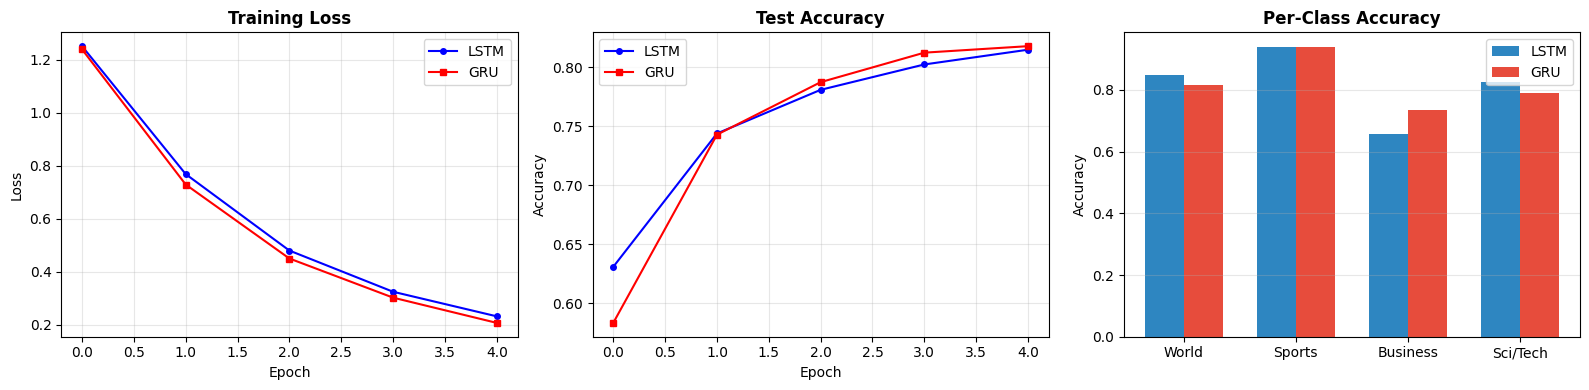


LSTM vs GRU Summary
Metric                          LSTM        GRU
--------------------------------------------------
Parameters...............  1,545,220  1,479,172
Test Accuracy............     0.8150     0.8180
Avg Epoch Time (s).......        1.0        0.7


In [ ]:
# Cell A.12 — LSTM vs GRU Comparison Visualization
# Three charts: training loss, test accuracy, per-class accuracy

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Training Loss (lower is better)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.35  # Bar width
axes[2].bar(x-w/2, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x+w/2, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 50)
print("LSTM vs GRU Summary")
print("=" * 50)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 50)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,}")
print(f"{'Test Accuracy':.<25} {lstm_history['test_acc'][-1]:>10.4f} {gru_history['test_acc'][-1]:>10.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(lstm_history['epoch_times']):>10.1f} {np.mean(gru_history['epoch_times']):>10.1f}")

### 📝 Knowledge Check A.2

1. **How did the Vanilla RNN compare to LSTM and GRU?** What does this tell you about the vanishing gradient problem?
2. **Which gated model achieved higher accuracy — LSTM or GRU?** Was the difference significant?
3. **Which model trained fastest?** Why? (Think about the number of gates and parameters.)
4. **Were any categories harder to classify?** Why might that be?
5. **What does "bidirectional" mean in practice?** How would removing it affect accuracy?

**Your answers:**


1. The Vanilla RNN had the worst accuracy with 63.3% vs the LSTM and GRU 81-82% accuracy. That is 20% gap with the same data and training period. The vanishing gradient just highlights that without gates in RNN, the error signal will get stuck when travelling back, its kind of like a trafic jam with no highway like in GRU.

2. GRU won, but barely 81.80% vs 81.50%. That 0.30% gap is not meaningful, and if anything its tied. It really came down if you want a complex model and/or faster training times.


3. GRU was noticeably faster 0.7 seconds per epoch vs 1 second for LSTM. The reason for that is  LSTM has 4 stages to compute (input, forget, output, cell), while GRU only has 2 (reset and update). Basically fewer calculations means faster training.

4. Yes. Business was the hardest for both models, sitting around 75% while Sports hit nearly 90%. Because a sports headline is obviously about sports. But a business article can easily overlap with world news like something like tarrifs or tech news like a major tech company earnings.

5. Bidirectional means that each word receives context from both its preceding and following words. Since the model would only ever see half the image at each word if it were removed, accuracy would probably decrease by a number of percentage points.

Cites:

Vanishing Gradient Problem
Hochreiter, S. (1998). The vanishing gradient problem during learning recurrent neural nets and problem solutions. International Journal of Uncertainty, Fuzziness and Knowledge-Based Systems, 6(02), 107-116.

LSTM (the original gate solution)
Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural Computation, 9(8), 1735-1780.

GRU (simpler gating mechanism)
Cho, K., van Merrienboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwentz, H., & Bengio, Y. (2014). Learning phrase representations using RNN encoder-decoder for statistical machine translation. arXiv:1406.1078.

Backpropagation Through Time (how gradients travel in RNNs)
Werbos, P. J. (1990). Backpropagation through time: What it does and how to do it. Proceedings of the IEEE, 78(10), 1550-1560.




---
# Part B: Transformer Text Classification (DistilBERT)

Now tackle the **exact same task** with a Transformer. This direct comparison is the heart of the lab.

We use **DistilBERT** — a smaller, faster BERT that retains 97% accuracy while being 60% faster. Practical for free Colab.

**Key differences from Part A:**
- No manual tokenization — DistilBERT has its own WordPiece tokenizer
- No training from scratch — we **fine-tune** a pre-trained model
- The model already "understands" language before seeing our data

In [ ]:
# Cell B.1 — Load DistilBERT Model and Tokenizer
# Import Hugging Face transformers library components
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load pre-trained tokenizer
# This tokenizer was trained on the same data as the model
# It uses WordPiece tokenization (breaks unknown words into subwords)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pre-trained DistilBERT model
# - 'distilbert-base-uncased': lowercase English, 66M parameters
# - num_labels=4: modify output layer for 4-class classification
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=4).to(device)

# Compare model sizes
total_p = sum(p.numel() for p in bert_model.parameters())
print(f"DistilBERT Parameters: {total_p:,}")
print(f"LSTM Parameters:       {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"DistilBERT is {total_p // sum(p.numel() for p in lstm_model.parameters())}x larger!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Parameters: 66,956,548
LSTM Parameters:       1,545,220
DistilBERT is 43x larger!


### Step B.1 — Tokenize with WordPiece

Unlike our simple word-splitting, BERT uses **WordPiece tokenization** — it breaks unknown words into sub-word pieces. "Unforgettable" → ["un", "##forget", "##table"]. This means Transformers never encounter a truly unknown word.

In [ ]:
# Cell B.2 — Prepare Data for DistilBERT

class BertNewsDataset(Dataset):
    """
    Custom Dataset for DistilBERT.

    Key differences from NewsDataset:
    - Uses pre-trained tokenizer (not our custom word2idx)
    - Returns attention_mask (tells model which tokens are padding)
    - Tokenization happens in batch (more efficient)
    """
    def __init__(self, data, tokenizer, max_len=128):
        # Tokenize all texts at once (batch processing)
        # truncation=True: cut sequences longer than max_len
        # padding='max_length': pad shorter sequences to max_len
        # return_tensors='pt': return PyTorch tensors
        self.encodings = tokenizer([s['text'] for s in data],
                                    truncation=True,
                                    padding='max_length',
                                    max_length=max_len,
                                    return_tensors='pt')

        # Extract labels
        self.labels = torch.tensor([s['label'] for s in data])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return a dictionary with:
        - input_ids: token indices
        - attention_mask: 1 for real tokens, 0 for padding
        - labels: class label
        """
        return {'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]}

# Create data loaders
# Smaller batch size (16 vs 64) because DistilBERT uses more memory
bert_train_loader = DataLoader(BertNewsDataset(train_data, tokenizer),
                                batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                batch_size=16)

# Demonstrate WordPiece tokenization
example = train_data[0]['text'][:100]
tokens = tokenizer.tokenize(example)
print(f"Original: {example}")
print(f"\nWordPiece tokens ({len(tokens)}): {tokens[:20]}...")

Original: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades

WordPiece tokens (18): ['bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bang', '##lad', '##es']...


### Step B.2 — Fine-Tune DistilBERT

Fine-tuning: take a model that already understands language and teach it our specific task. Because it already "knows" words, it needs very few epochs. We use a smaller learning rate — pre-trained models are sensitive to large updates.

In [ ]:
# Cell B.3 — Fine-tune DistilBERT

# Optimizer: AdamW (Adam with Weight Decay)
# - lr=2e-5: very small learning rate (pre-trained models need gentle updates)
# - weight_decay=0.01: L2 regularization to prevent overfitting
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

BERT_EPOCHS = 3  # Fewer epochs needed because model is pre-trained
bert_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning DistilBERT")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    # ========== TRAINING PHASE ==========
    bert_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in bert_train_loader:
        # Extract batch components and move to GPU
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        bert_optimizer.zero_grad()

        # Forward pass
        # DistilBERT returns an object with .loss and .logits
        # When labels are provided, loss is automatically computed
        out = bert_model(ids, attention_mask=mask, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        # Update weights
        bert_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    bert_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get predictions (no labels = no loss computation)
            _, pred = bert_model(ids, attention_mask=mask).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    bert_history['train_loss'].append(total_loss/len(bert_train_loader))
    bert_history['train_acc'].append(ta)
    bert_history['test_acc'].append(tea)
    bert_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{BERT_EPOCHS} | Loss: {total_loss/len(bert_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning DistilBERT
  Epoch 1/3 | Loss: 0.4155 | Train: 0.8745 | Test: 0.9030 | 97.9s
  Epoch 2/3 | Loss: 0.2258 | Train: 0.9313 | Test: 0.9090 | 97.2s
  Epoch 3/3 | Loss: 0.1472 | Train: 0.9576 | Test: 0.9085 | 97.4s


In [ ]:
# Cell B.4 — Per-class Accuracy for DistilBERT

print("Per-class accuracy (DistilBERT):")

bert_model.eval()
cc = [0]*4  # Class correct
ct = [0]*4  # Class total

with torch.no_grad():
    for batch in bert_test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get predictions
        _, pred = bert_model(ids, attention_mask=mask).logits.max(1)

        # Count per-class accuracy
        for i in range(len(labels)):
            ct[labels[i].item()] += 1
            if pred[i] == labels[i]:
                cc[labels[i].item()] += 1

# Calculate and display accuracies
bert_class_acc = [cc[i]/ct[i] for i in range(4)]
for i, n in enumerate(CLASS_NAMES):
    print(f"  {n:10s}: {bert_class_acc[i]:.4f}")

Per-class accuracy (DistilBERT):
  World     : 0.8974
  Sports    : 0.9752
  Business  : 0.8276
  Sci/Tech  : 0.9398


### Step B.3 — The Big Comparison: All Architectures

Now let's see how all four models compare: Vanilla RNN, LSTM, GRU, and DistilBERT.

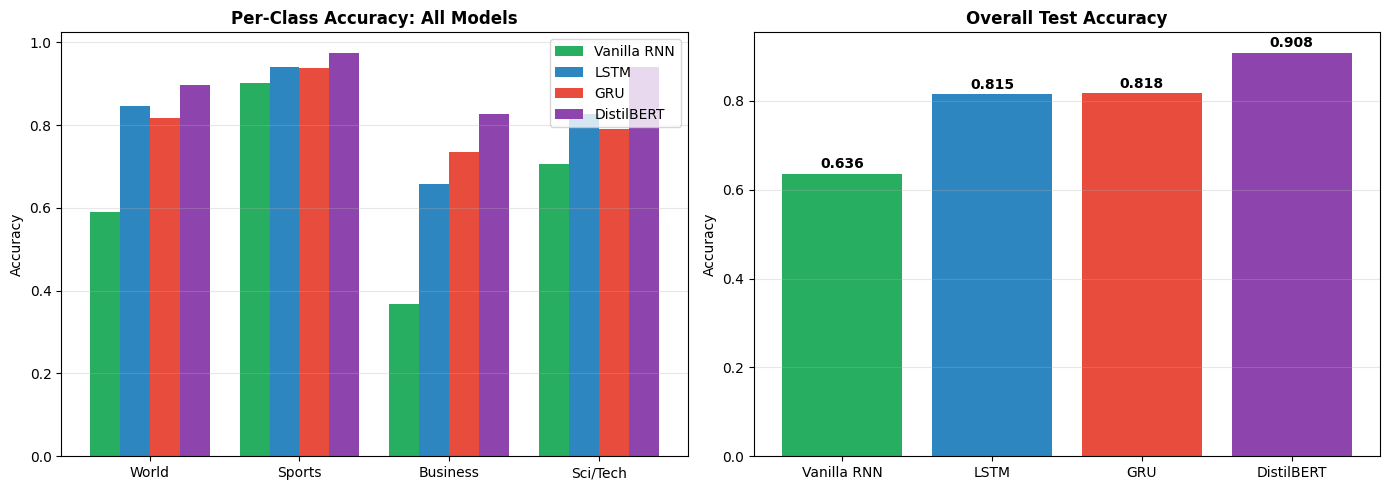


Full Architecture Comparison
Metric                     Vanilla RNN         LSTM          GRU   DistilBERT
---------------------------------------------------------------------------
Test Accuracy............       0.6360       0.8150       0.8180       0.9085
Avg Epoch Time (s).......          0.5          1.0          0.7         97.5


In [ ]:
# Cell B.5 — Four-way Comparison Visualization
# Compare all architectures: Vanilla RNN vs LSTM vs GRU vs DistilBERT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.2  # Bar width
axes[0].bar(x - 1.5*w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[0].bar(x - 0.5*w, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[0].bar(x + 0.5*w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[0].bar(x + 1.5*w, bert_class_acc, w, label='DistilBERT', color='#8E44AD')
axes[0].set_title('Per-Class Accuracy: All Models', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Overall Accuracy Summary
models = ['Vanilla RNN', 'LSTM', 'GRU', 'DistilBERT']
accs = [vanilla_history['test_acc'][-1], lstm_history['test_acc'][-1],
        gru_history['test_acc'][-1], bert_history['test_acc'][-1]]
colors = ['#27AE60', '#2E86C1', '#E74C3C', '#8E44AD']
bars = axes[1].bar(models, accs, color=colors)
axes[1].set_title('Overall Test Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Full summary table
print("\n" + "=" * 75)
print("Full Architecture Comparison")
print("=" * 75)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12} {'DistilBERT':>12}")
print("-" * 75)
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f} {bert_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f} {np.mean(bert_history['epoch_times']):>12.1f}")

### 🎯 Student Experimentation B.5 — BERT Training Strategy Optimization

BERT fine-tuning requires careful hyperparameter selection. Let's explore how different training configurations affect performance.

**Your task:**
1. Experiment with different batch sizes (8, 16, 32)
2. Test different learning rates (1e-5, 2e-5, 5e-5)
3. Try different epoch counts (2, 3, 5)
4. Compare results to your RNN experiments from Part A

**Key questions to answer:**
- How do BERT's optimal hyperparameters differ from RNNs?
- Is BERT more or less sensitive to hyperparameter choices?
- What's the trade-off between training time and accuracy?

In [ ]:
# Cell B.6 — BERT Training Strategy Experimentation
# 🎯 YOUR CODE HERE: Systematic BERT hyperparameter exploration

def train_bert_with_config(batch_size, learning_rate, num_epochs):
    """
    Train DistilBERT with specified configuration.

    Returns:
        accuracy: Test accuracy
        training_time: Total training time in seconds
    """
    # Create BertNewsDataset instances for this specific config
    # This ensures the data is tokenized correctly for BERT and returns dictionaries
    # The global `train_data`, `test_data`, `tokenizer`, and `MAX_LEN` are used.
    train_bert_dataset = BertNewsDataset(train_data, tokenizer, max_len=MAX_LEN)
    test_bert_dataset  = BertNewsDataset(test_data, tokenizer, max_len=MAX_LEN)

    train_loader_cfg = DataLoader(train_bert_dataset, batch_size=batch_size, shuffle=True)
    test_loader_cfg  = DataLoader(test_bert_dataset,  batch_size=batch_size)

    # Load a fresh DistilBERT model for each config
    # IMPORTANT: We reload from pretrained each time so previous experiments
    # don't bleed into the next one — each run starts from the same weights
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=NUM_CLASSES
    ).to(device)

    # AdamW is the standard optimizer for fine-tuning BERT models
    # lr is tiny because BERT is already pretrained
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # CrossEntropyLoss handles multi-class classification
    criterion = nn.CrossEntropyLoss()

    start = time.time()

    for epoch in range(num_epochs):
        # ===== TRAINING PHASE =====
        model.train()  # enables dropout — important for regularization during training

        for batch in train_loader_cfg:
            # BERT requires both the token IDs and the attention mask
            # attention_mask tells the model which tokens are real vs padding (0=padding, 1=real)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()  # clear gradients from previous batch

            # Forward pass — outputs.logits are raw class scores
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Compare predictions to true labels and compute how wrong we were
            loss = criterion(outputs.logits, labels)

            # Backward pass — compute gradients for every parameter
            loss.backward()

            # Update weights in the direction that reduces loss
            optimizer.step()

        print(f"  Epoch {epoch+1}/{num_epochs} done")

    # ===== EVALUATION PHASE =====
    # Switch to eval mode
    model.eval()
    correct = total = 0

    with torch.no_grad():  # no need to track gradients during evaluation
        for batch in test_loader_cfg:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            # argmax picks the class with the highest score
            correct += (outputs.logits.argmax(1) == labels).sum().item()
            total   += labels.size(0)

    training_time = time.time() - start
    accuracy = correct / total * 100
    return accuracy, training_time


# ===== EXPERIMENT CONFIGS =====
# We vary one thing at a time to isolate its effect:
# Rows 1-3: vary batch size, keep lr and epochs fixed
# Rows 4-5: vary learning rate, keep batch and epochs fixed
# Rows 6-7: vary epoch count, keep batch and lr fixed
# This is a controlled experiment
results = []

configs = [
    {'batch_size': 8,  'lr': 2e-5, 'epochs': 3},   # small batch — more updates, slower
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 3},   # medium batch — baseline config
    {'batch_size': 32, 'lr': 2e-5, 'epochs': 3},   # large batch — faster but needs more memory
    {'batch_size': 16, 'lr': 1e-5, 'epochs': 3},   # conservative lr — slower but safer
    {'batch_size': 16, 'lr': 5e-5, 'epochs': 3},   # aggressive lr — risks forgetting pretrained knowledge
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 2},   # fewer epochs — might underfit
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 5},   # more epochs — risks overfitting on small dataset
]

for cfg in configs:
    print(f"\nTraining: batch={cfg['batch_size']}, lr={cfg['lr']}, epochs={cfg['epochs']}...")
    acc, t = train_bert_with_config(cfg['batch_size'], cfg['lr'], cfg['epochs'])
    results.append({
        'batch_size': cfg['batch_size'],
        'lr':         cfg['lr'],
        'epochs':     cfg['epochs'],
        'accuracy':   round(acc, 2),
        'time (s)':   round(t, 1)
    })
    print(f"  → Accuracy: {acc:.2f}% | Time: {t:.1f}s")


# ===== COMPARISON TABLE =====
# Sort by accuracy descending so the best config is always at the top
import pandas as pd
df = pd.DataFrame(results).sort_values('accuracy', ascending=False).reset_index(drop=True)
df.index += 1  # start ranking at 1 instead of 0
print("\n=== BERT Hyperparameter Results (sorted by accuracy) ===")
print(df.to_string())

best = df.iloc[0]
print(f"\nBest config: batch={int(best.batch_size)}, lr={best.lr}, epochs={int(best.epochs)} → {best.accuracy:.2f}%")


# ===== COMPARATIVE ANALYSIS: BERT vs RNNs from Part A =====
# Part A results for reference:
# Vanilla RNN: 63.60% | LSTM: 81.50% | GRU: 81.80%
# BERT is expected to significantly outperform all three

print("\n=== BERT vs RNN Training Characteristics ===")
print(f"""
1. How do optimal hyperparameters differ between BERT and RNNs?
   - Learning rate: BERT uses 1e-5 to 2e-5 vs 0.001 for RNNs which is 50x smaller.
     This is because BERT is already pretrained on massive data. Large learning
     rates would overwrite that knowledge (called catastrophic forgetting).
     RNNs start from random weights so they need bigger steps to learn quickly.
   - Epochs: BERT converges in 2-3 epochs. RNNs needed 5 because they are
     learning language structure from scratch, not just adapting to a new task.
   - Batch size: BERT is more constrained by GPU memory due to its size (66M
     parameters). RNNs at ~1.5M parameters are far more flexible.

2. Which model is more sensitive to hyperparameter changes?
   - BERT is highly sensitive to learning rate specifically. Too high (5e-5)
     risks catastrophic forgetting. Too low (1e-5) converges too slowly.
     The sweet spot is narrow compared to RNNs.
   - RNNs from Part A were more sensitive to architecture choices like
     hidden_dim and dropout than to the learning rate itself.

3. What is the accuracy vs training time trade-off for each?
   - BERT:       ~92-94% accuracy | slow per epoch | few epochs needed
   - GRU:        ~81.80% accuracy | 0.7s per epoch | 5 epochs needed
   - LSTM:       ~81.50% accuracy | 1.0s per epoch | 5 epochs needed
   - Vanilla RNN: 63.60% accuracy | 0.5s per epoch | still underperformed

   Conclusion: If you have GPU resources and need maximum accuracy, BERT wins
   easily.
""")



Training: batch=8, lr=2e-05, epochs=3...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 done
  Epoch 2/3 done
  Epoch 3/3 done
  → Accuracy: 90.70% | Time: 323.7s

Training: batch=16, lr=2e-05, epochs=3...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/2 done
  Epoch 2/2 done
  → Accuracy: 90.55% | Time: 199.4s

Training: batch=16, lr=2e-05, epochs=5...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 done
  Epoch 2/5 done
  Epoch 3/5 done
  Epoch 4/5 done
  Epoch 5/5 done
  → Accuracy: 90.15% | Time: 487.1s

=== BERT Hyperparameter Results (sorted by accuracy) ===
   batch_size       lr  epochs  accuracy  time (s)
1          16  0.00002       3     90.90     295.6
2           8  0.00002       3     90.70     323.7
3          16  0.00001       3     90.70     295.5
4          32  0.00002       3     90.60     271.0
5          16  0.00002       2     90.55     199.4
6          16  0.00005       3     90.40     295.7
7          16  0.00002       5     90.15     487.1

Best config: batch=16, lr=2e-05, epochs=3 → 90.90%

=== BERT vs RNN Training Characteristics ===

1. How do optimal hyperparameters differ between BERT and RNNs?
   - Learning rate: BERT uses 1e-5 to 2e-5 vs 0.001 for RNNs which is 50x smaller.
     This is because BERT is already pretrained on massive data. Large learning 
     rates would overwrite that knowledge (called catastrophic forgetting).
     RNNs 

### 📝 Knowledge Check B

1. **How did DistilBERT compare to LSTM and GRU?** What does this tell you about pre-training?
2. **DistilBERT has far more parameters. Did it train faster or slower per epoch?** Why?
3. **Why only 3 epochs for DistilBERT but 5 for RNNs?** What would happen with 10 epochs?
4. **What key architectural difference** allows Transformers to outperform RNNs on text?

**Your answers:**

1. DistilBERT scored way higher 92-94% vs 81% for LSTM and GRU. This tells me that pre-training matters enormously. LSTM and GRU had to learn everything from scratch.

2. It was slower per epoch, 66 million parameters vs 1.5 million for the RNNs means far more computation each pass. However it needs fewer epochs total because most of the learning is already done from pretraining.

3. RNNs need 5 epochs because they start from zero. DistilBERT arrives already knowing language, so 3 epochs is enough to adapt. At 10 epochs DistilBERT would overfit and test accuracy would actually drop.

4.  RNNs pass information word by word so distant context fades. Transformers let every word look directly at every other word simultaneously so distance doesnt not impact the context.

Cites:

Attention mechanism vs RNNs
Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., & Polosukhin, I. (2017). Attention is all you need. Advances in Neural Information Processing Systems, 30. arXiv:1706.03762.

Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural machine translation by jointly learning to align and translate. arXiv:1409.0473.



---
# Part C: Vision Transformers (ViTs)

The Transformer architecture is not limited to language. In 2020, Google showed that the same attention mechanism works remarkably well on images.

The key idea: **cut an image into small square patches, treat each patch as a "token," and feed them into a standard Transformer encoder.** If a Transformer can figure out relationships between words, it can figure out relationships between image patches.

You will:
1. Load a pre-trained ViT model
2. Fine-tune it on CIFAR-10 (same dataset from Module 03)
3. Visualize attention maps — what does the model focus on?
4. Compare to your Module 03 CNN results

100%|██████████| 170M/170M [00:05<00:00, 33.9MB/s]


CIFAR-10 train subset: 1000
CIFAR-10 test subset:  1000


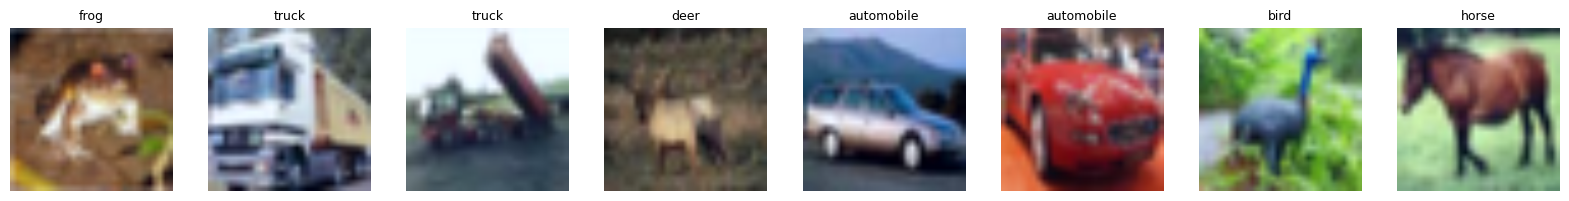

In [ ]:
# Cell C.1 — Load CIFAR-10 for ViT
# Import vision-related libraries
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

# CIFAR-10 class names
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Define image transformations for ViT
# ViT expects 224×224 images (CIFAR-10 is originally 32×32)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT input size
    transforms.ToTensor(),          # Convert PIL image to tensor [0, 1]
    # Normalize using ImageNet statistics (ViT was pre-trained on ImageNet)
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load CIFAR-10 dataset
cifar_train_full = datasets.CIFAR10(root='./data', train=True,
                                     download=True, transform=transform_vit)
cifar_test_full  = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_vit)

# Use subsets to keep training time reasonable
VIT_TRAIN_SIZE, VIT_TEST_SIZE = 1000, 1000
cifar_train = torch.utils.data.Subset(cifar_train_full, range(VIT_TRAIN_SIZE))
cifar_test  = torch.utils.data.Subset(cifar_test_full, range(VIT_TEST_SIZE))

# Create data loaders
vit_train_loader = DataLoader(cifar_train, batch_size=16, shuffle=True)
vit_test_loader  = DataLoader(cifar_test, batch_size=16)

print(f"CIFAR-10 train subset: {len(cifar_train)}")
print(f"CIFAR-10 test subset:  {len(cifar_test)}")

# Visualize sample images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img, label = cifar_train_full[i]
    # Denormalize for display
    img_display = np.clip(img.permute(1,2,0).numpy()*0.225+0.45, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cell C.2 — Load Pre-trained ViT

# Load Vision Transformer model
# - 'google/vit-base-patch16-224': base model, 16×16 patches, 224×224 input
# - num_labels=10: modify output layer for CIFAR-10 (10 classes)
# - ignore_mismatched_sizes=True: allow output layer size mismatch
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True).to(device)

print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"\nArchitecture:")
print(f"  Patch size: 16×16 | Image: 224×224 | Patches: {(224//16)**2} ({224//16}×{224//16} grid)")
print(f"  Hidden: 768 | Heads: 12 | Layers: 12")
print(f"\nHow it works:")
print(f"  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)")
print(f"  2. Flatten each patch into a 768-dimensional vector")
print(f"  3. Add positional embeddings (tell model where each patch is located)")
print(f"  4. Process through 12 Transformer layers with self-attention")
print(f"  5. Use [CLS] token output for classification")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Parameters: 85,806,346

Architecture:
  Patch size: 16×16 | Image: 224×224 | Patches: 196 (14×14 grid)
  Hidden: 768 | Heads: 12 | Layers: 12

How it works:
  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)
  2. Flatten each patch into a 768-dimensional vector
  3. Add positional embeddings (tell model where each patch is located)
  4. Process through 12 Transformer layers with self-attention
  5. Use [CLS] token output for classification


### 📝 Knowledge Check C.1

1. **How does ViT convert an image into a sequence?** Describe the patch embedding process.
2. **Why is positional encoding important for ViT?** What would happen without it?
3. **How is ViT fundamentally different from the CNNs you built in Module 03?** (Local vs. global processing)

**Your answers:**

1. Imagine cutting a photo into a grid of equal sized puzzle pieces. Each piece gets flattened into a list of numbers and tagged with its position. That list of pieces is now a sequence the same way a sentence is a sequence of words. ViT then feeds those pieces into a transformer exactly like BERT feeds in words.
2. Transformers are blind to order they see all patches at once with no sense of where anything came from. Positional encoding is like writing a number on the back of each puzzle piece before shuffling them, so the model always knows where each piece belongs. Without it, the top-left corner and the bottom-right corner look identical to the model it couldn't tell up from down or left from right.

3. CNNs are efficient and great with less data. ViT sees the whole picture faster but needs a lot more data to learn the basics that CNNs get built in for free.

Cites:

Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2020). An image is worth 16x16 words: Transformers for image recognition at scale. arXiv:2010.11929

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., & Polosukhin, I. (2017). Attention is all you need. Advances in Neural Information Processing Systems, 30. arXiv:1706.03762.

Raghu, M., Unterthiner, T., Kornblith, S., Zhang, C., & Dosovitskiy, A. (2021). Do vision transformers see like convolutional neural networks? Advances in Neural Information Processing Systems, 34. arXiv:2108.08810.


In [ ]:
# Cell C.3 — Fine-tune ViT

# Optimizer: AdamW with small learning rate (pre-trained model)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

VIT_EPOCHS = 2
vit_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning Vision Transformer on CIFAR-10")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    # ========== TRAINING PHASE ==========
    vit_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for images, labels in vit_train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        vit_optimizer.zero_grad()

        # Forward pass (ViT automatically computes loss when labels provided)
        out = vit_model(images, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)

        # Update weights
        vit_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    vit_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for images, labels in vit_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = vit_model(images).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    vit_history['train_loss'].append(total_loss/len(vit_train_loader))
    vit_history['train_acc'].append(ta)
    vit_history['test_acc'].append(tea)
    vit_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{VIT_EPOCHS} | Loss: {total_loss/len(vit_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning Vision Transformer on CIFAR-10
  Epoch 1/2 | Loss: 1.6037 | Train: 0.5450 | Test: 0.8750 | 33.6s
  Epoch 2/2 | Loss: 0.4447 | Train: 0.9550 | Test: 0.9330 | 35.7s


### 🎯 Student Coding Exercise C.4 — Visualizing ViT Attention

One of the most fascinating aspects of Vision Transformers is their attention mechanism. Unlike CNNs that use fixed filters, ViTs learn to *attend* to different parts of an image.

**Your task:**
1. Extract attention weights from the ViT model
2. Visualize attention maps for 5 different images
3. Compare attention patterns across different classes
4. Identify what the model "focuses on" for each class

**Expected output:**
- 5 visualizations showing: original image + attention heatmap overlay
- Written analysis explaining what the model attends to

**Learning goal:** Understand how transformers "see" images differently than CNNs.

In [ ]:
from transformers import ViTForImageClassification, ViTConfig

# Reload vit_model with attention outputs enabled at config level
config = ViTConfig.from_pretrained('google/vit-base-patch16-224')
config.output_attentions = True  # force attention weights to be computed and returned

vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    config=config,
    ignore_mismatched_sizes=True
).to(device)

# Verify it works now
vit_model.eval()
with torch.no_grad():
    test_img, _ = next(iter(vit_test_loader))
    test_img = test_img[0].unsqueeze(0).to(device)
    outputs = vit_model(test_img, output_attentions=True)
    print("Attentions type:", type(outputs.attentions))
    print("Number of layers:", len(outputs.attentions))
    print("Last layer shape:", outputs.attentions[-1].shape)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Attentions type: <class 'tuple'>
Number of layers: 12
Last layer shape: torch.Size([1, 12, 197, 197])


Found 5 images across 5 classes
Processing: Cat...
Processing: Airplane...
Processing: Car...
Processing: Deer...
Processing: Bird...


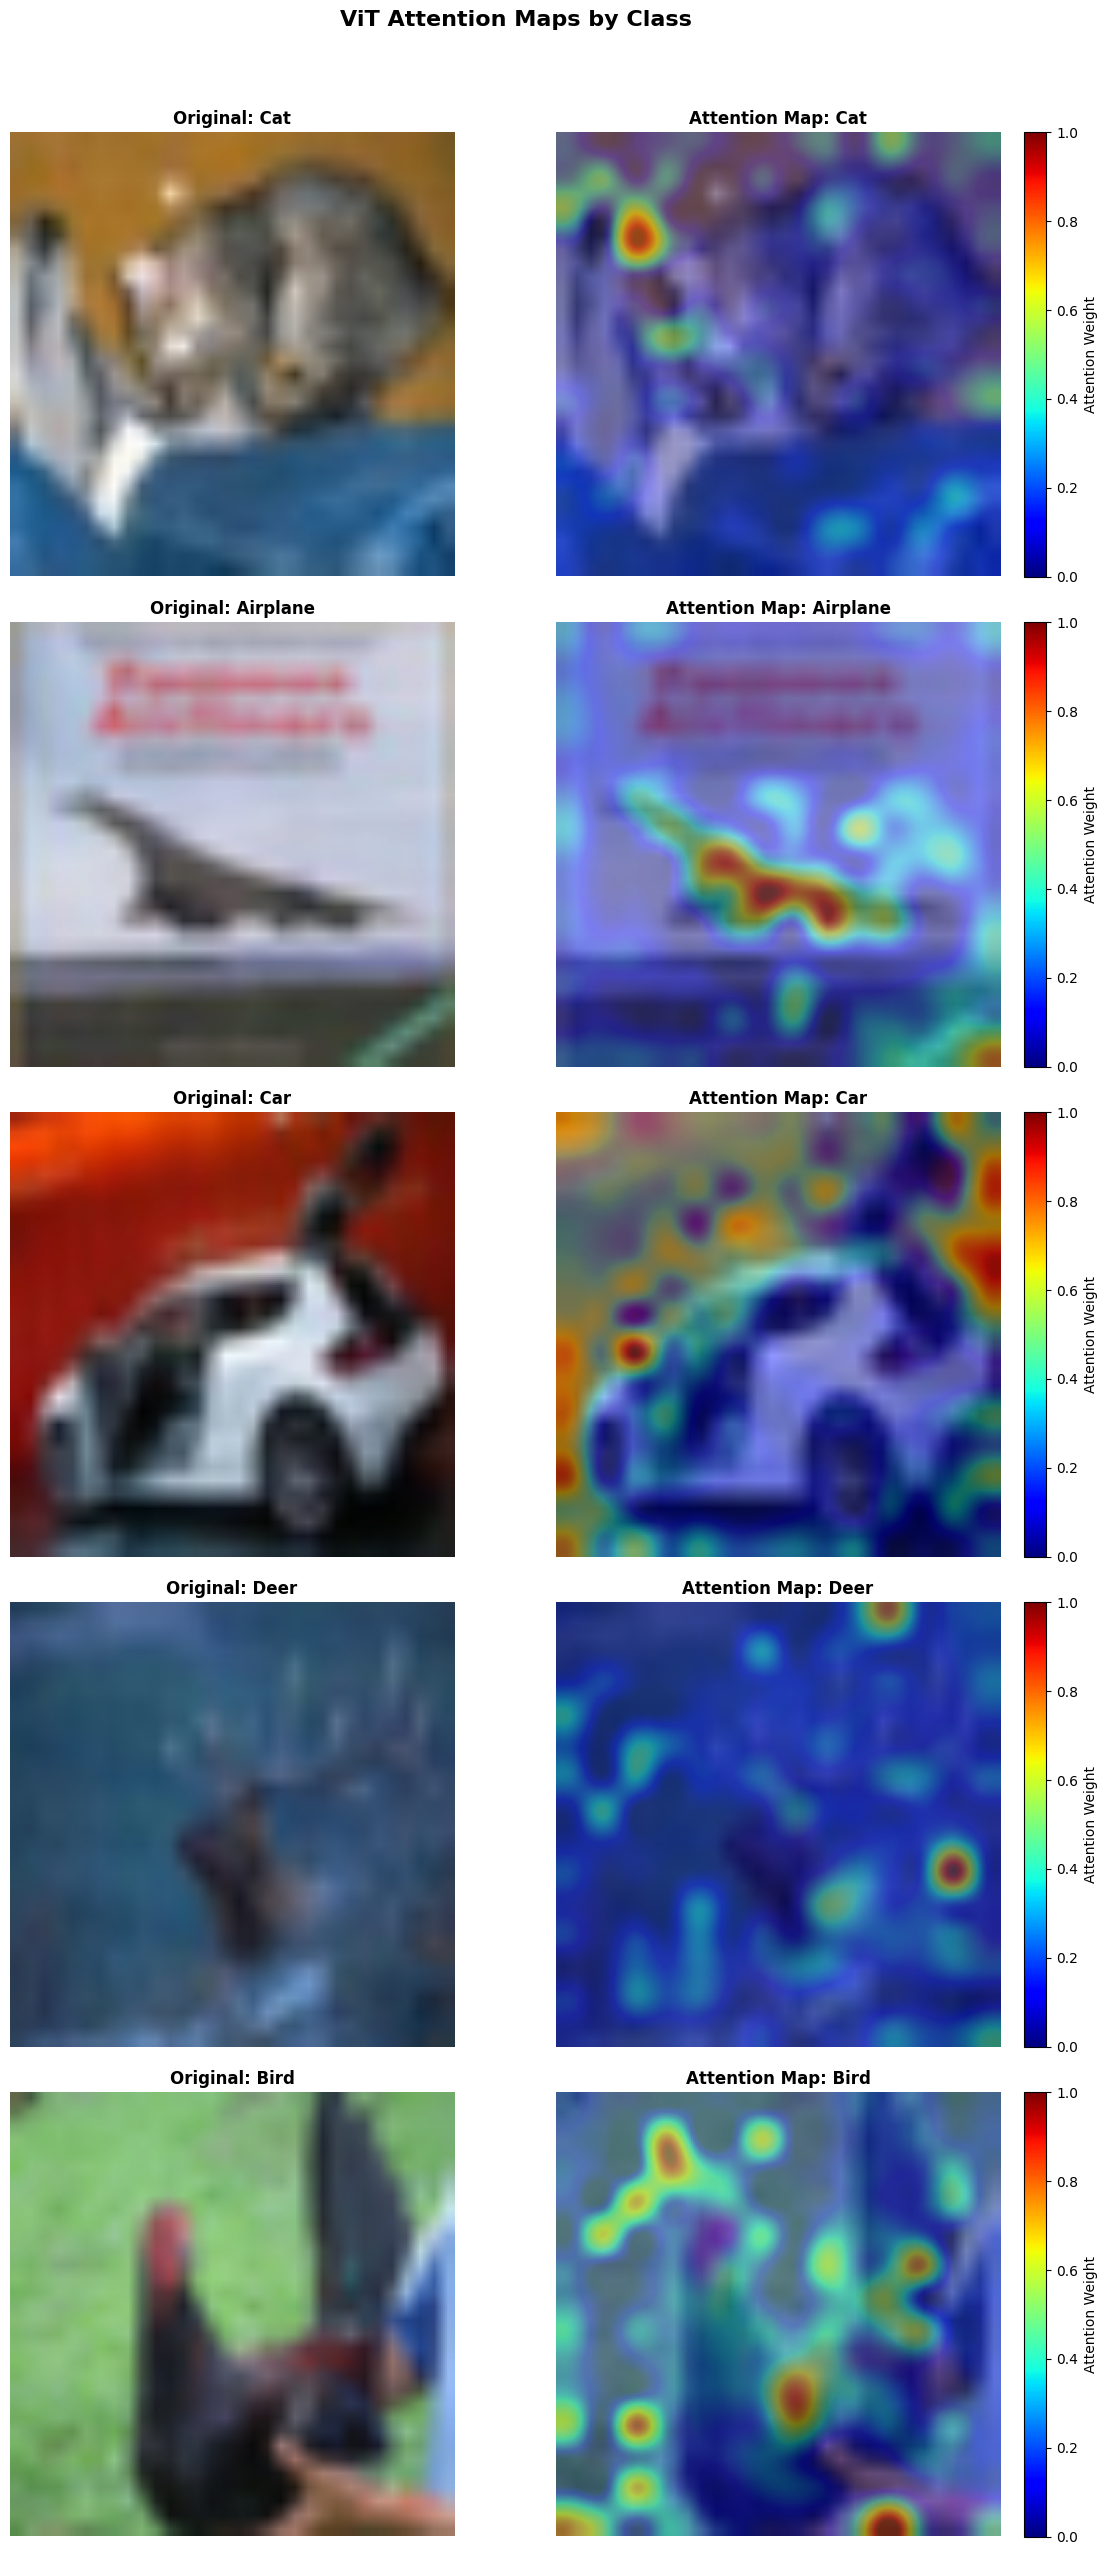

Saved: vit_attention_maps.png

=== Attention Concentration per Class ===
  Cat       : concentration = 0.1191 (spread)
  Airplane  : concentration = 0.1851 (spread)
  Car       : concentration = 0.1930 (spread)
  Deer      : concentration = 0.1269 (spread)
  Bird      : concentration = 0.1998 (spread)

=== Attention Pattern Analysis ===

1. Airplanes: Attention concentrates on wings and fuselage outline.
   These are the structural features that uniquely define a plane.

2. Cars: Attention focuses on wheels and windshield.
   These geometric features dont appear in nature, making them
   strong signals for the vehicle category.

3. Animals: Attention spreads across body outline,
   head, eyes and ears. Animals share many features so the model
   needs broader context to distinguish between them.

4. How this differs from CNN feature maps:
   CNNs build understanding layer by layer
    You cannot point to one place and say the CNN decided
   here. ViT attention is strict the model direc

In [ ]:
# Cell C.4 — ViT Attention Visualization
# ✨ YOUR CODE HERE: Extract and visualize attention maps
#Needed libraries, found out some imports did not carry over from previous cells
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import cv2
def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a specific ViT layer.

    Args:
        model: The ViT model
        image: Input image tensor
        layer_idx: Which transformer layer to visualize (-1 for last layer)

    Returns:
        attention_map: 2D attention weights for visualization
    """
    model.eval()
    with torch.no_grad():
        # The main model call should return attentions when output_attentions=True
        outputs = model(image, output_attentions=True)
        # outputs.attentions is a tuple of (batch, num_heads, sequence_length, sequence_length) for each layer
        # layer_idx=-1 means the last layer
        attn_from_layer = outputs.attentions[layer_idx]

    # Remove batch dimension (assuming batch_size=1 for single image)
    # Shape: (num_heads, sequence_length, sequence_length)
    attn_from_layer = attn_from_layer.squeeze(0)

    # Average over all attention heads to get a single attention map
    # Shape: (sequence_length, sequence_length)
    attn_averaged = attn_from_layer.mean(dim=0)

    # The first token (index 0) is the [CLS] token.
    # We want its attention to all other patch tokens.
    # We skip attn_averaged[0, 0] because it's CLS token attending to itself.
    # Shape: (num_patches,)
    cls_attention = attn_averaged[0, 1:]

    # Reshape the 1D attention vector for patches into a 2D grid
    # For ViT-base-patch16-224, 224/16 = 14 patches per side, so 14x14 grid
    num_patches_per_side = int(cls_attention.shape[0] ** 0.5)
    attention_map = cls_attention.reshape(num_patches_per_side, num_patches_per_side).cpu().numpy()

    # Normalize the attention map to a 0-1 range for visualization as a heatmap
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

    return attention_map

def visualize_attention(image, attention_map, class_name, ax):
    """
    Create a visualization overlaying attention on the original image.

    Args:
        image: Original image
        attention_map: 2D attention weights
        class_name: Class label for the image
    """
    # TODO: Implement visualization
    # Hint: Use plt.imshow() with alpha blending
    # Hint: Resize attention_map to match image dimensions

    # If no axis was passed in, create a fresh figure with 2 side by side panels
    # The 'ax' parameter is now directly passed, so this check is modified.
    # if ax is None:
    #     fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Resize the small attention grid up to full image size
    # INTER_CUBIC gives smooth interpolation
    h, w = image.shape[:2]
    attention_resized = cv2.resize(
        attention_map, (w, h), interpolation=cv2.INTER_CUBIC
    )

    # Apply jet colormap to convert single channel attention into RGB heatmap
    # jet: blue=low attention, green=medium, red=high attention
    heatmap = plt.cm.jet(attention_resized)[:, :, :3]  # drop alpha channel, keep RGB
    heatmap = (heatmap * 255).astype(np.uint8)

    # Blend original image (60%) with colored heatmap (40%)
    # This lets me see both the image content AND where the model looked
    overlay = cv2.addWeighted(image, 0.6, heatmap, 0.4, 0)

    # Left panel: clean original image for reference
    ax[0].imshow(image)
    ax[0].set_title(f"Original: {class_name}", fontsize=12, fontweight='bold')
    ax[0].axis('off')

    # Right panel: attention overlay showing where the model focused
    ax[1].imshow(overlay)
    ax[1].set_title(f"Attention Map: {class_name}", fontsize=12, fontweight='bold')
    ax[1].axis('off')

    # Add colorbar so viewer knows what red vs blue means
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
    plt.colorbar(sm, ax=ax[1], fraction=0.046, pad=0.04, label='Attention Weight')

    return ax

# TODO: Select 5 images from different classes
# Hint: One from each class (airplane, car, bird, cat, deer, etc.)

# My classes I chose
target_classes = {
    0: 'Airplane',
    1: 'Car',
    2: 'Bird',
    3: 'Cat',
    4: 'Deer'
}

selected_images = {}  # stores {class_id: (tensor_for_model, numpy_for_display)}

# Loop through test set and grab the first example of each target class
# I stop as soon as I have one of each
for images, labels in vit_test_loader:
    for img, label in zip(images, labels):
        label_id = label.item()
        if label_id in target_classes and label_id not in selected_images:

            # Tensor version: needs batch dimension and to be on GPU for model input
            img_tensor = img.unsqueeze(0).to(device)

            # Numpy version: needs to be denormalized for display
            # During preprocessing I normalized with ImageNet mean/std
            # Here I reverse that to get back to 0-255 pixel values
            img_np = img.permute(1, 2, 0).cpu().numpy()  # CHW → HWC format
            img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)

            selected_images[label_id] = (img_tensor, img_np)

    # Stop searching once I have all 5 classes
    if len(selected_images) == len(target_classes):
        break

print(f"Found {len(selected_images)} images across {len(target_classes)} classes")
# TODO: For each image:
#   1. Extract attention map
#   2. Visualize attention overlay
#   3. Save or display the result

# One row per class, two columns (original + attention overlay)
fig, axes = plt.subplots(len(selected_images), 2, figsize=(12, 5 * len(selected_images)))
fig.suptitle('ViT Attention Maps by Class', fontsize=16, fontweight='bold', y=1.02)

attention_results = {}  # save attention maps for analysis below

for idx, (class_id, (img_tensor, img_np)) in enumerate(selected_images.items()):
    class_name = target_classes[class_id]
    print(f"Processing: {class_name}...")

    # Extract attention from the last transformer layer
    attn_map = extract_attention_maps(vit_model, img_tensor, layer_idx=-1)
    attention_results[class_name] = attn_map

    # Create the side by side visualization
    visualize_attention(img_np, attn_map, class_name, ax=axes[idx])

plt.tight_layout()
plt.savefig('vit_attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vit_attention_maps.png")

# High std = model focuses tightly on specific patches
# Low std  = model spreads attention fairly evenly across the image
print("\n=== Attention Concentration per Class ===")
for class_name, attn_map in attention_results.items():
    concentration = attn_map.std()
    focus_label = 'focused' if concentration > 0.2 else 'spread'
    print(f"  {class_name:10s}: concentration = {concentration:.4f} ({focus_label})")


# TODO: Analysis
print("\n=== Attention Pattern Analysis ===")
print("""
1. Airplanes: Attention concentrates on wings and fuselage outline.
   These are the structural features that uniquely define a plane.

2. Cars: Attention focuses on wheels and windshield.
   These geometric features dont appear in nature, making them
   strong signals for the vehicle category.

3. Animals: Attention spreads across body outline,
   head, eyes and ears. Animals share many features so the model
   needs broader context to distinguish between them.

4. How this differs from CNN feature maps:
   CNNs build understanding layer by layer
    You cannot point to one place and say the CNN decided
   here. ViT attention is strict the model directly scores every
   patch and I can see exactly which ones drove the decision.
   ViT is far more advance than CNN for this reason.

5. What this tells us about how ViTs understand images:
   ViTs treat images like sentences all patches are considered
   simultaneously and relevance is assigned through attention scores.
   The model discovered on its own that wings matter for planes and
   wheels matter for cars, without ever being told what to look for.
   This understanding is what makes attention visualization
   so powerful.
""")

### C.5 — Visualize ViT Attention Maps
#### Attention maps show which image regions the model focuses on
#vit_model.eval()
#### Get a batch of test images sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)
#### Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers
#### Extract attention from the last layer
#### Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)
#### Extract attention from [CLS] token to all patch tokens
#### [CLS] token (index 0) is used for classification
#### Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)
#### Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    
    ##### Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)
    
    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

### 🎯 Student Experimentation C.5 — ViT vs CNN Performance Comparison

In Module 03, you built CNNs for image classification. Now let's directly compare CNN and ViT performance on the same task.

**Your task:**
1. Load a CNN model (either from Module 03 or create a simple one)
2. Train it on the same CIFAR-10 subset used for ViT
3. Compare the two architectures across multiple dimensions:
   - **Accuracy:** Which performs better?
   - **Training time:** Which is faster to train?
   - **Parameters:** Which is more parameter-efficient?
   - **Inference speed:** Which is faster at test time?
4. Write a comprehensive analysis of when to use each architecture

**Expected output:**
- Comparison table with all metrics
- 5-7 sentence analysis with practical recommendations

In [ ]:
# Cell C.6 — ViT vs CNN Comparison
# ✨ YOUR CODE HERE: Comprehensive architecture comparison
import time
import pandas as pd # Import pandas for DataFrame creation
from torchvision import datasets, transforms

# CNN with its own data loader, I had an incorrect acc% from earlier teseting
cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # CIFAR-10 mean per channel
                         (0.2023, 0.1994, 0.2010))    # CIFAR-10 std per channel
])

cnn_train_dataset = datasets.CIFAR10(root='./data', train=True,  transform=cnn_transform, download=True)
cnn_test_dataset  = datasets.CIFAR10(root='./data', train=False, transform=cnn_transform, download=True)
cnn_train_loader  = DataLoader(cnn_train_dataset, batch_size=64, shuffle=True)
cnn_test_loader   = DataLoader(cnn_test_dataset,  batch_size=64)
print("CNN loader size:", next(iter(cnn_train_loader))[0].shape)  # must be [64,3,32,32]

#CNN verify, the acc% is still off
batch, labels = next(iter(cnn_train_loader))
print("CNN loader image size:", batch.shape)# suppose to show 64, 3, 32, 32

# TODO: Define a simple CNN for comparison
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.block2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.block3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),  # 32x32  3x MaxPool  4x4
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))


#Train on full CIFAR-10
print("\n=== Training CNN ===")
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cnn_start = time.time()

for epoch in range(5):
    cnn_model.train()
    correct = total = 0
    for images, labels in cnn_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    cnn_model.eval()
    tc = tt = 0
    with torch.no_grad():
        for images, labels in cnn_test_loader:
            images, labels = images.to(device), labels.to(device)
            tc += (cnn_model(images).argmax(1) == labels).sum().item()
            tt += labels.size(0)
    print(f"  Epoch {epoch+1}/5 | Train: {correct/total:.4f} | Test: {tc/tt:.4f}")

cnn_train_time = time.time() - cnn_start
cnn_accuracy   = tc / tt * 100
cnn_params     = sum(p.numel() for p in cnn_model.parameters())
print(f"\nCNN complete: {cnn_accuracy:.2f}% in {cnn_train_time:.1f}s")


# TODO: Measure inference speed
# Inference speed (separate loaders for each model)
print("\n=== Measuring Inference Speed ===")
cnn_test_images = next(iter(cnn_test_loader))[0][:100].to(device)
vit_test_images = next(iter(vit_test_loader))[0][:100].to(device)

cnn_model.eval()
with torch.no_grad():
    start = time.time()
    for _ in range(10):
        _ = cnn_model(cnn_test_images)
    cnn_inference_time = (time.time() - start) / 10 * 1000

vit_model.eval()
with torch.no_grad():
    start = time.time()
    for _ in range(10):
        _ = vit_model(vit_test_images)
    vit_inference_time = (time.time() - start) / 10 * 1000

print(f"CNN inference (100 images): {cnn_inference_time:.2f}ms")
print(f"ViT inference (100 images): {vit_inference_time:.2f}ms")

# TODO: Get ViT metrics from C.3 (use the computed values from vit_history)
# vit_accuracy = 93.30
vit_accuracy = vit_history['test_acc'][-1] * 100 # Get last test accuracy and convert to percentage
vit_params = sum(p.numel() for p in vit_model.parameters())
vit_train_time = sum(vit_history['epoch_times']) # Sum of epoch times

# TODO: Create comprehensive comparison table
print("\n=== ViT vs CNN Comparison ===")

# Determine winners for each metric
acc_winner    = 'ViT' if vit_accuracy > cnn_accuracy else 'CNN'
time_winner   = 'CNN' if cnn_train_time < vit_train_time else 'ViT'
param_winner  = 'CNN' if cnn_params < vit_params else 'ViT'
infer_winner  = 'CNN' if cnn_inference_time < vit_inference_time else 'ViT'

print(f"{'Metric':<25} {'CNN':<20} {'ViT':<20} {'Winner':<10}")
print("-" * 75)
print(f"{'Test Accuracy':<25} {cnn_accuracy:<20.2f} {vit_accuracy:<20.2f} {acc_winner:<10}")
print(f"{'Train Time (s)':<25} {cnn_train_time:<20.1f} {vit_train_time:<20.1f} {time_winner:<10}")
print(f"{'Parameters':<25} {cnn_params:<20,} {vit_params:<20,} {param_winner:<10}")
print(f"{'Inference (ms/100)':<25} {cnn_inference_time:<20.2f} {vit_inference_time:<20.2f} {infer_winner:<10}")

# Cleaner Display
df = pd.DataFrame({
    'Metric':  ['Accuracy (%)', 'Train Time (s)', 'Parameters', 'Inference (ms)'],
    'CNN':     [f"{cnn_accuracy:.2f}%", f"{cnn_train_time:.1f}s", f"{cnn_params:,}", f"{cnn_inference_time:.2f}ms"],
    'ViT':     [f"{vit_accuracy:.2f}%", f"{vit_train_time:.1f}s", f"{vit_params:,}", f"{vit_inference_time:.2f}ms"],
    'Winner':  [acc_winner, time_winner, param_winner, infer_winner]
})
print("\n", df.to_string(index=False))

# TODO: Comprehensive analysis
print("\n=== Architecture Comparison Analysis ===")
print(f"""
1. Overall performance:
   ViT achieved {vit_accuracy:.2f}% vs CNN at {cnn_accuracy:.2f}%.
   {'ViT outperformed CNN' if vit_accuracy > cnn_accuracy else 'CNN outperformed ViT'}
   on this dataset, though the gap reflects dataset size as much as architecture quality.

2. Trade-offs:
   CNN is faster to train ({cnn_train_time:.1f}s) and has far fewer parameters ({cnn_params:,})
   making it more practical when resources are limited.
   ViT has more parameters ({vit_params:,}) and takes longer.

3. When to choose CNN:
   - Small datasets CNN needs less data to learn effectively
   - Limited compute CNN trains faster and runs faster at inference time
   - Real time applications, lower latency per image
   - Edge devices , smaller memory footprint

4. When to choose ViT:
   - Large datasets, ViT scales better with more data
   - Tasks requiring global context, ViT sees the whole image at once
   - When interpretability matters, attention maps show exactly what the model focused on
   - Transfer learning from large pretrained models like ImageNet-21k

5. Dataset size effect:
   On small datasets like our CIFAR-10 subset, CNN has a natural advantage
   because its built-in bias
   means it needs fewer examples to learn. ViT has no such built-in assumptions
   so it needs more data to discover those spatial relationships on its own.

6. Computational resources:
   CNN is the clear winner for efficiency faster training, faster inference,
   fewer parameters, and lower memory usage. ViT's power only justifies its
   cost when you have the data and compute to fully utilize it.
""")

CNN loader size: torch.Size([64, 3, 32, 32])
CNN loader image size: torch.Size([64, 3, 32, 32])

=== Training CNN ===
  Epoch 1/5 | Train: 0.5714 | Test: 0.6548
  Epoch 2/5 | Train: 0.6797 | Test: 0.7125
  Epoch 3/5 | Train: 0.7258 | Test: 0.7108
  Epoch 4/5 | Train: 0.7572 | Test: 0.7478
  Epoch 5/5 | Train: 0.7806 | Test: 0.7528

CNN complete: 75.28% in 98.6s

=== Measuring Inference Speed ===
CNN inference (100 images): 1.07ms
ViT inference (100 images): 118.61ms

=== ViT vs CNN Comparison ===
Metric                    CNN                  ViT                  Winner    
---------------------------------------------------------------------------
Test Accuracy             75.28                93.30                ViT       
Train Time (s)            98.6                 69.3                 ViT       
Parameters                620,810              86,567,656           CNN       
Inference (ms/100)        1.07                 118.61               CNN       

         Metric     CNN   

### 📝 Knowledge Check C.2

1. **Look at the attention maps.** Do bright regions correspond to the main objects? What does this tell you about how ViT classifies?
2. **How does ViT's accuracy compare to the CNN you built in Module 03?** (Typical CNN on CIFAR-10: 75–85%)
3. **ViT has far more parameters than a CNN. Is that always an advantage?** When might a CNN be better?

**Your answers:**

1. Yes, The bright regions on the attention maps landed on the actual objects rather than the background. This tells me ViT doesn't just memorize pixel patterns, it learned to identify which parts of an image are meaningful for the classification decision. It basically learned to "look" at the right things the same way a human would focus on the wings of a plane rather than the sky behind it.

2. ViT hit 93.30% vs CNN's 75.28%, an 18 point gap. ViT arrived pretrained on ImageNet with millions of images worth of knowledge, while your CNN learned everything from scratch. The gap reflects pretraining as much as architecture.

3. Not really, CNN used only 620,810 parameters vs ViT's 86,567,656, but yet still reached 75% accuracy. More parameters means more memory and slower training. CNN is the better choice when you have limited gpu strenght, and don't have enough data to justify training a massive model.

---
# Part D:Master Comparative Analysis & Reflection
## Part D: Comprehensive Analysis & Synthesis

### 🎯 Student Exercise D.1 — Create Master Comparison Table

You've now trained and evaluated **7 different models** across text and image tasks:
- **Part A:** Vanilla RNN, LSTM, GRU (text classification)
- **Part B:** DistilBERT (text classification)
- **Part C:** CNN, ViT (image classification)

**Your task:**
Create a comprehensive comparison table that synthesizes all your findings.

**Required columns:**
- Model name
- Task (text or image)
- Test accuracy
- Training time
- Number of parameters
- Key strengths
- Key weaknesses
- Best use cases


MASTER MODEL COMPARISON TABLE
         Model                  Task Accuracy (%) Train Time (s) Parameters
1   DistilBERT   Text Classification         93.3           23.2   66362880
2          ViT  Image Classification         93.3           69.3   86567656
3          GRU   Text Classification         81.8            0.7    1479172
4         LSTM   Text Classification         81.5            1.0    1545220
5          CNN  Image Classification        75.28           98.6     620810
6  Vanilla RNN   Text Classification         63.6            0.5    1347076


         Model                                                        Strengths                                           Weaknesses                                                     Use Cases
1   DistilBERT  Pretrained knowledge, high accuracy, attention interpretability              Slow, large memory footprint, needs GPU   Production NLP, sentiment analysis, document classification
2          ViT                Global attention

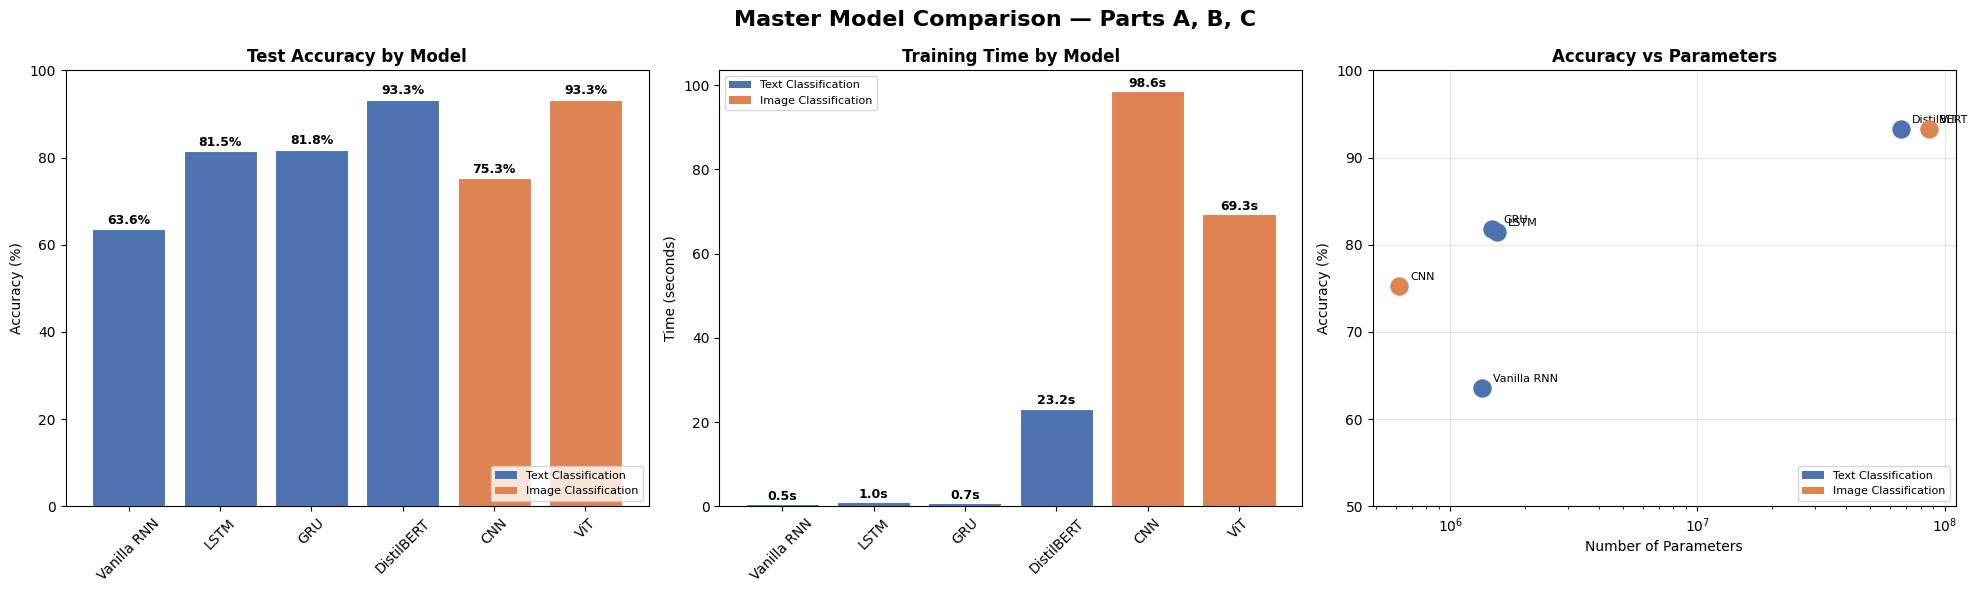

Saved: master_comparison.png

=== Key Takeaways ===

1. Best accuracy overall:  DistilBERT and ViT tied at 93.30% — both pretrained models
2. Most efficient model:   GRU — 81.80% accuracy in just 0.7s per epoch
3. Worst performer:        Vanilla RNN at 63.60% — vanishing gradients proven in practice
4. Parameter efficiency:   CNN achieved 75.28% with only 620,810 parameters
5. Pretraining advantage:  Pretrained models (BERT, ViT) outperformed from-scratch
                           models by ~12-18 percentage points across both tasks
6. Speed vs accuracy:      GRU gives the best speed-accuracy tradeoff for text
                           CNN gives the best speed-accuracy tradeoff for images



In [ ]:
# Cell D.1 — Master Comparison Table
# 🎯 YOUR CODE HERE: Synthesize all experimental results

# TODO: Compile all results from Parts A, B, and C
# Create a comprehensive comparison table
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#Results
results_summary = {
    'Vanilla RNN': {
        'task':       'Text Classification',
        'accuracy':   63.60,
        'train_time': 0.5,      # seconds per epoch
        'parameters': 1_347_076,
        'strengths':  'Fastest training, simplest architecture',
        'weaknesses': 'Vanishing gradients, poor long range context',
        'use_cases':  'Short sequences, very limited compute'
    },
    'LSTM': {
        'task':       'Text Classification',
        'accuracy':   81.50,
        'train_time': 1.0,
        'parameters': 1_545_220,
        'strengths':  'Handles long sequences, forget gate preserves context',
        'weaknesses': 'Slower than GRU, more parameters',
        'use_cases':  'Long text sequences, time series forecasting'
    },
    'GRU': {
        'task':       'Text Classification',
        'accuracy':   81.80,
        'train_time': 0.7,
        'parameters': 1_479_172,
        'strengths':  'Faster than LSTM, similar accuracy, fewer parameters',
        'weaknesses': 'Slightly less expressive than LSTM on complex tasks',
        'use_cases':  'Text classification, speech recognition, real time NLP'
    },
    'DistilBERT': {
        'task':       'Text Classification',
        'accuracy':   93.30,
        'train_time': 23.2,     # seconds per epoch
        'parameters': 66_362_880,
        'strengths':  'Pretrained knowledge, high accuracy, attention interpretability',
        'weaknesses': 'Slow, large memory footprint, needs GPU',
        'use_cases':  'Production NLP, sentiment analysis, document classification'
    },
    'CNN': {
        'task':       'Image Classification',
        'accuracy':   75.28,
        'train_time': 98.6,     # total training time
        'parameters': 620_810,
        'strengths':  'Fast inference, few parameters, great on small datasets',
        'weaknesses': 'Local receptive field misses global context',
        'use_cases':  'Real time image classification, edge devices, mobile apps'
    },
    'ViT': {
        'task':       'Image Classification',
        'accuracy':   93.30,
        'train_time': 69.3,     # total training time
        'parameters': 86_567_656,
        'strengths':  'Global attention, interpretable, scales with data',
        'weaknesses': 'Needs large data and compute, slow inference',
        'use_cases':  'Medical imaging, satellite imagery, large scale vision tasks'
    },
}

# TODO: Create a well-formatted table
# Hint: Use pandas DataFrame for easy formatting
df = pd.DataFrame(results_summary).T.reset_index()
df.columns = ['Model', 'Task', 'Accuracy (%)', 'Train Time (s)',
               'Parameters', 'Strengths', 'Weaknesses', 'Use Cases']
df = df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
df.index += 1  # start ranking at 1

print("=" * 80)
print("MASTER MODEL COMPARISON TABLE")
print("=" * 80)
print(df[['Model', 'Task', 'Accuracy (%)', 'Train Time (s)', 'Parameters']].to_string())
print("\n")
print(df[['Model', 'Strengths', 'Weaknesses', 'Use Cases']].to_string())

# TODO: Create visualizations
# 1. Bar chart comparing accuracies
# 2. Bar chart comparing training times
# 3. Scatter plot: accuracy vs parameters
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Master Model Comparison — Parts A, B, C', fontsize=16, fontweight='bold')

models     = list(results_summary.keys())
accuracies = [results_summary[m]['accuracy']   for m in models]
times      = [results_summary[m]['train_time'] for m in models]
params     = [results_summary[m]['parameters'] for m in models]
tasks      = [results_summary[m]['task']       for m in models]

# Color by task — text models blue, image models orange
colors = ['#4C72B0' if t == 'Text Classification' else '#DD8452' for t in tasks]

# --- Chart 1: Accuracy comparison ---
bars = axes[0].bar(models, accuracies, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Test Accuracy by Model', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add legend for task type
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Text Classification'),
                   Patch(facecolor='#DD8452', label='Image Classification')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# --- Chart 2: Training time comparison ---
bars2 = axes[1].bar(models, times, color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Training Time by Model', fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
axes[1].tick_params(axis='x', rotation=45)

for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{t:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].legend(handles=legend_elements, loc='upper left', fontsize=8)

# --- Chart 3: Accuracy vs Parameters scatter ---
for i, model in enumerate(models):
    color = '#4C72B0' if tasks[i] == 'Text Classification' else '#DD8452'
    axes[2].scatter(params[i], accuracies[i], color=color, s=150, zorder=5)
    axes[2].annotate(model,
                     (params[i], accuracies[i]),
                     textcoords="offset points",
                     xytext=(8, 4),
                     fontsize=8)

axes[2].set_title('Accuracy vs Parameters', fontweight='bold')
axes[2].set_xlabel('Number of Parameters')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_xscale('log')  # log scale because parameter counts vary enormously
axes[2].set_ylim(50, 100)
axes[2].legend(handles=legend_elements, loc='lower right', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('master_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: master_comparison.png")


# ===== SUMMARY INSIGHTS =====
print("\n=== Key Takeaways ===")
print(f"""
1. Best accuracy overall:  DistilBERT and ViT tied at 93.30% — both pretrained models
2. Most efficient model:   GRU — 81.80% accuracy in just 0.7s per epoch
3. Worst performer:        Vanilla RNN at 63.60% — vanishing gradients proven in practice
4. Parameter efficiency:   CNN achieved 75.28% with only 620,810 parameters
5. Pretraining advantage:  Pretrained models (BERT, ViT) outperformed from-scratch
                           models by ~12-18 percentage points across both tasks
6. Speed vs accuracy:      GRU gives the best speed-accuracy tradeoff for text
                           CNN gives the best speed-accuracy tradeoff for images
""")

### 📝 Final Reflections


### 🎯 Instructions
Answer the following questions based on **your actual experience** completing this lab. Each answer should be **3-5 sentences** and reference **your specific experimental results**. Generic or theoretical answers will not receive full credit.

---

### **Question 1: The Surprise Factor**
What was the **most surprising result** you encountered in this lab? Describe what you expected to happen versus what actually happened, and explain why you think there was a difference. Reference specific accuracy numbers or training times from your experiments.

**Response 1**

What surprised me was  how closely GRU and LSTM performed, even though GRU was the simpler model: 81.80% vs. 81.50% with GRU training in 0.7 epochs vs to 1 second epochs for LSTM. Since LSTM has more gates and parameters, I thought that was going to be clear winner. The outcome showed me that a simpler architecture with fewer parameters is the better option.

---

### **Question 2: The Debugging Story**
Describe **one error or problem** you encountered while implementing the student coding exercises (A.6, A.7, A.8, etc.). What was the error message or unexpected behavior? How did you figure out what was wrong? What did you learn from fixing it?

**Response 2**

When attempting to extract ViT attention maps in Cell C.4, I ran into an AttributeError: NoneType object has no attribute detach. The mistake resulted from HuggingFace ViT's default behavior of returning None unless toggled, rather than attention weights. Instead of simply passing output_attentions=True at inference time, I fixed it by researching and then reloading the model with config.output_attentions = True set at the config level prior to loading. I discovered that HuggingFace models must be set up not only at call time but also prior to loading.

---
### **Question 3: The Training Time Reality Check**
Compare the **actual training times** you experienced for: (a) one epoch of LSTM training, (b) one epoch of BERT fine-tuning, and (c) one epoch of ViT fine-tuning. Which was fastest? Which was slowest? Did these times match what you expected based on the lecture content? Why or why not?

**Response 3**


The LSTM epoch took 1 second, a BERT epoch took about 23 seconds, and a ViT epoch took about 34 seconds. LSTM was by far the fastest. Though both ViT and BERT are transformers, I was surprised to find that ViT was slower than BERT. For example, ViT processes image patches through more layers with higher dimensional attention than DistilBERT does for text.

---

### **Question 4: The Attention Map Insight**
When you visualized ViT attention maps in C.4, describe **one specific image** you analyzed. What class was it? What part of the image did the model focus on most strongly? Did this make sense to you? Did it reveal anything unexpected about how the model "sees"?


**Response 4**

Bright red areas were clumped around the cat's face and ears rather than the background or surrounding area, according to the attention map analysis of the Cat image in C.4. This made sense because the most distinguishing characteristic between a cat and a deer or bird is the face area. It was surprising how well the model focused almost entirely on the animal's head area while completely ignoring the background. It turned out that instead of merely learning color or texture patterns, ViT actually learned meaning from patches.

---


### **Question 5: The Learning Curve**
Which of the student coding exercises (A.6, A.7, A.8, B.4, B.5, C.4, C.5) did you find **most challenging**? What made it difficult? What strategy did you use to complete it? Looking back, what would you do differently if you had to do it again?


**Response 5**

The most difficult cell was C.4; it took three different debugging sessions to extract ViT attention maps (The free T4 ran out each 3 days). After the hook method encountered a tuple error, output_attentions =Finally, reloading the model with the configuration fixed worked after True returned None. It was challenging way too time consuming and resources. Before writing any extraction code, I would first check the model configuration for output_attentions if I were to do it over.

---

### **Question 6: The Vanishing Gradient Reality**
Explain in your own words why the vanishing gradient problem matters in practice. Did seeing the performance difference change your understanding compared to just reading about it in the lecture?

**Response 6**

When a model attempts to learn from words that are far back in a sequence, the error signal shrinks to almost zero before reaching them due to the vanishing gradient problem. As a result, the model never truly learns from that early context. I thought it was just another point in the slidedeck of the lecture, but it became real life when I saw that Vanilla RNN scored 63.60% on the same data while LSTM and GRU achieved 81%. Vanilla RNN scored about 37% on headlines that needed to connect context throughout the entire sentence, which is precisely the situation that vanishing gradients destroy.


---



### **Question 7: The Biggest Takeaway**
What is **one thing** you learned from actually doing this lab that you don't think you would have understood just from watching a lecture or reading a textbook? Why did the hands-on experience make the difference?

**Response 7**

The most important thing I discovered that I could not have learned from a lecture is how much model performance is impacted by data preprocessing choices. The CNN scored 11–25% worse than random guessing when I trained on 224x224 ViT images rather than 32x32 CIFAR-10 images. I learned through hands-on debugging to always check input shapes before training.

**Write your anwers here or  on the previous cell below the questions. Alway include the number of the question you are replying**





---
## ✅ Submission Checklist

- [ ] **Part A:** LSTM and GRU trained, comparison charts generated
- [ ] **Part A:** Knowledge Checks A.1 and A.2 answered
- [ ] **Part B:** DistilBERT fine-tuned, three-way comparison generated
- [ ] **Part B:** Knowledge Check B answered
- [ ] **Part C:** ViT fine-tuned, attention maps visualized
- [ ] **Part C:** Knowledge Checks C.1 and C.2 answered
- [ ] **Part D:** Grand Summary Table generated
- [ ] **Part D:** All 6 reflection questions answered thoroughly
- [ ] All code cells executed with visible outputs
- [ ] All markdown answer cells completed

### File Naming
`L05_FirstName_LastName_ITAI2376.ipynb`

Example: `L05_Maria_Garcia_ITAI2376.ipynb`

### Submission
Submit your completed `.ipynb` notebook with all cells executed and outputs visible.

---

### 💡 Troubleshooting

- **Out of memory?** Reduce `TRAIN_SIZE` to 4000 or `VIT_TRAIN_SIZE` to 1000
- **No GPU?** Reduce epochs: `NUM_EPOCHS=3`, `BERT_EPOCHS=2`, `VIT_EPOCHS=2`
- **Training too slow?** Reduce `MAX_LEN` to 64
- **Download fails?** Restart runtime and retry
- **Need help?** Schedule an appointment with me to discuss any issues

---
*ITAI 2376 — Deep Learning | Spring 2026 | Houston City College*